# E-Commerce Sales Analysis: Customer Segmentation & Risk Insights

# E-Commerce Sales Analysis: Customer Segmentation & Risk Insights

## Project Overview
This project analyzes a UK-based online retail dataset containing transactions
from December 2010 to December 2011. The goal is to understand sales trends,
customer behavior, and return risks to support business decision-making.

**Dataset:** Online Retail Dataset (UCI Machine Learning Repository)  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn  
**Key Areas:** Time series analysis, RFM segmentation, Return risk analysis

## Table of Contents
1. Data Cleaning & Pre-processing
2. Feature Engineering
3. Exploratory Data Analysis (EDA)
4. Retail vs Wholesale Analysis
5. RFM Customer Segmentation
6. Return & Risk Analysis
7. Key Business Insights


## Data Source & Pre-processing Notes
The raw data was pre-cleaned in Excel and split into two parts:
- **Sales data** (`sales_df`) — all successful transactions
- **Return data** (`return_df`) — all cancelled/returned orders

Further cleaning steps are applied below.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Online_Retail_Clean.xlsx to Online_Retail_Clean.xlsx


In [2]:
#importing all the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#loading the sales data

sales_df = pd.read_excel("Online_Retail_Clean.xlsx", sheet_name="sales_data")
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [4]:
#laoding the return data

return_df = pd.read_excel("Online_Retail_Clean.xlsx", sheet_name="return_data")
return_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


## 1. Data cleaning and Pre-processing

In [5]:
#checking the datatypes for the the sales data

sales_df.dtypes

,0
InvoiceNo,int64
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object


In [6]:
#changing the InvoiceNo datatype to string

sales_df["InvoiceNo"] = sales_df["InvoiceNo"].astype(str)

In [7]:
#validating the change

sales_df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object


In [8]:
#checking the datatypes for the return data

return_df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object


In [9]:
#rechecking the sales data for missing values

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396337 entries, 0 to 396336
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    396337 non-null  object        
 1   StockCode    396337 non-null  object        
 2   Description  396337 non-null  object        
 3   Quantity     396337 non-null  int64         
 4   InvoiceDate  396337 non-null  datetime64[ns]
 5   UnitPrice    396337 non-null  float64       
 6   CustomerID   396337 non-null  int64         
 7   Country      396337 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 24.2+ MB


In [10]:
#rechecking the return data for missing values

return_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8539 entries, 0 to 8538
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    8539 non-null   object        
 1   StockCode    8539 non-null   object        
 2   Description  8539 non-null   object        
 3   Quantity     8539 non-null   int64         
 4   InvoiceDate  8539 non-null   datetime64[ns]
 5   UnitPrice    8539 non-null   float64       
 6   CustomerID   8539 non-null   int64         
 7   Country      8539 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 533.8+ KB


In [11]:
#checking for any duplicate in the sales data

duplicates = sales_df.duplicated()
sales_df[duplicates]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
506,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
516,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
526,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
528,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
544,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920,United Kingdom
...,...,...,...,...,...,...,...,...
396109,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446,United Kingdom
396123,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446,United Kingdom
396126,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446,United Kingdom
396133,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446,United Kingdom


We have found some duplicate values but we will not remove all the duplicates as a "InvoiceNo" can be duplicated (one Invoice = many products), "CustomerID" can be duplicated (Repeat customers),
and so on. So, we will only removes those rows which are exactly duplicated.

In [12]:
#using drop_duplicates method to delete the rows which are exactly duplicates

sales_df = sales_df.drop_duplicates()

In [13]:
#checking the dimension of the sales dataset

sales_df.shape

(391150, 8)

In [14]:
#checking the dimension of the return dataset

return_df.shape

(8539, 8)

In [15]:
#same as sales data, removing the rows which are exactly duplicates

return_df = return_df.drop_duplicates()

In [16]:
#checking the dimension of the return data

return_df.shape

(8506, 8)

## 2. Feature engineering

In [17]:
# creating a Revenue column for sales data

sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

# creating a Revenue loss column as ReturnValue in return data
return_df["ReturnValue"] = return_df["Quantity"] * return_df["UnitPrice"]

In [18]:
# extraxting the day, month, year, Month-Year, time, hour and day name in sales data

sales_df["Day"] = sales_df["InvoiceDate"].dt.day
sales_df["Month"] = sales_df["InvoiceDate"].dt.month
sales_df["Year"] = sales_df["InvoiceDate"].dt.year
sales_df["MonthYear"] = sales_df["InvoiceDate"].dt.to_period("M")
sales_df["Time"] = sales_df["InvoiceDate"].dt.time
sales_df["Hours"] = sales_df["InvoiceDate"].dt.hour
sales_df["DayOfWeek"] = sales_df["InvoiceDate"].dt.day_name()


In [19]:
# extraxting the day, month, year, Month-Year, time, hour and day name in return data

return_df["Day"] = return_df["InvoiceDate"].dt.day
return_df["Month"] = return_df["InvoiceDate"].dt.month
return_df["Year"] = return_df["InvoiceDate"].dt.year
return_df["MonthYear"] = return_df["InvoiceDate"].dt.to_period("M")
return_df["Time"] = return_df["InvoiceDate"].dt.time
return_df["DayOfWeek"] = return_df["InvoiceDate"].dt.day_name()

In [20]:
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,1,12,2010,2010-12,08:26:00,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,12,2010,2010-12,08:26:00,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,1,12,2010,2010-12,08:26:00,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,12,2010,2010-12,08:26:00,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,12,2010,2010-12,08:26:00,8,Wednesday


In [21]:
return_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ReturnValue,Day,Month,Year,MonthYear,Time,DayOfWeek
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom,-4.65,1,12,2010,2010-12,09:49:00,Wednesday
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom,-19.80,1,12,2010,2010-12,10:24:00,Wednesday
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96,1,12,2010,2010-12,10:24:00,Wednesday
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96,1,12,2010,2010-12,10:24:00,Wednesday
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom,-6.96,1,12,2010,2010-12,10:24:00,Wednesday


## 3. EDA(Exploritory Data Analysis)

For understanding the data and give meaningful insights. We are starting with the Sales data first.

### 3.1 EDA for Total Sales data (Retail + Wholesale)

In [22]:
#using .describe() method to understand any data anomalies

sales_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Day,Month,Year,Hours
count,391150.000000,391150,391150.000000,391150.000000,391150.000000,391150.000000,391150.000000,391150.000000,391150.000000
mean,13.145300,2011-07-10 19:37:34.766713600,2.874372,15295.171456,22.337281,15.043433,7.602459,2010.934631,12.722991
min,1.000000,2010-12-01 08:26:00,0.040000,12346.000000,0.060000,1.000000,1.000000,2010.000000,6.000000
25%,2.000000,2011-04-07 11:16:00,1.250000,13969.000000,4.950000,7.000000,5.000000,2011.000000,11.000000
50%,6.000000,2011-07-31 12:05:00,1.950000,15159.000000,11.900000,15.000000,8.000000,2011.000000,13.000000
75%,12.000000,2011-10-20 12:57:00,3.750000,16794.000000,19.800000,22.000000,11.000000,2011.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000,168469.600000,31.000000,12.000000,2011.000000,20.000000
std,180.807831,NaN,4.284738,1710.339033,310.932442,8.652538,3.414883,0.247176,2.275997


**As we can the max "Quantity", `Revenue` and `UnitPrice` are significantly high compare to the rest**

**This sales data has both Retail and Wholesales so we can assume the high numbers are the bulk wholesale orders**

**Let us continue our `EDA` with Retail and wholesale both**

In [23]:
# observing the KPIs

summary = {
    "Total Revenue": sales_df["Revenue"].sum(),
    "Total Orders": sales_df["InvoiceNo"].nunique(),
    "Total Products": sales_df["StockCode"].nunique(),
    "Total Quantity Sold": sales_df["Quantity"].sum(),
    "Total Customers": sales_df["CustomerID"].nunique()
}

sales_summary_df = pd.DataFrame(summary, index=["Value"])
sales_summary_df

,Total Revenue,Total Orders,Total Products,Total Quantity Sold,Total Customers
Value,8737227.64,18402,3659,5141784,4334


**Overall business at a glance: This business processed 18,402 unique orders from 4,334 customers between December 2010 and December 2011, generating a total gross revenue of £8.74 million. With 3,659 unique products sold and over 5.1 million units moved,it is clearly indicating that this is a high-volume driven business (well-established e-commerce business rather than a niche seller).**

#### Time series analysis

In [24]:
# looking for the sales trend month by month

monthly_sales = sales_df.groupby("MonthYear")["Revenue"].sum()
monthly_sales

,Revenue
MonthYear,
2010-12,565199.56
2011-01,562682.91
2011-02,442293.59
2011-03,583143.85
2011-04,454440.88
2011-05,659242.49
2011-06,653264.92
2011-07,591603.79
2011-08,635514.38


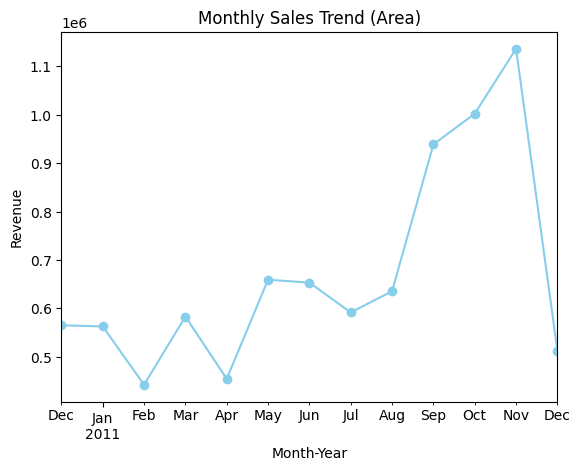

In [25]:
monthly_sales.plot(kind="line", marker="o", color="skyblue")

plt.title("Monthly Sales Trend (Area)")
plt.xlabel("Month-Year")
plt.ylabel("Revenue")

plt.show()

**Revenue grew strongly in the second half of 2011, with a sharp spike in November. Thus it is mainly a B2B business, the `Revenue` is high in the re-stocking period little before the festive months. January has a stable sales likely for the Valentine's weeks and February show a dip — likely post-holiday slowdown. March sales got stable (May be for the Easter egg festival helds in March-April approximately) but April has weird dip (We can't surely identify the trend pattern because we don't have previous years data). From the month of May the business grows likely for the Edinburgh Fringe Festival, Christmas and the New year festive time. The business should plan inventory and staffing well ahead from the August–November window to avoid stockouts during peak demand.**

In [26]:
# defining correct weekday order so the chart doesn't sort alphabetically
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# grouping by day
day_revenue = sales_df.groupby("DayOfWeek")["Revenue"].sum().reindex(day_order)
day_orders  = sales_df.groupby("DayOfWeek")["InvoiceNo"].nunique().reindex(day_order)

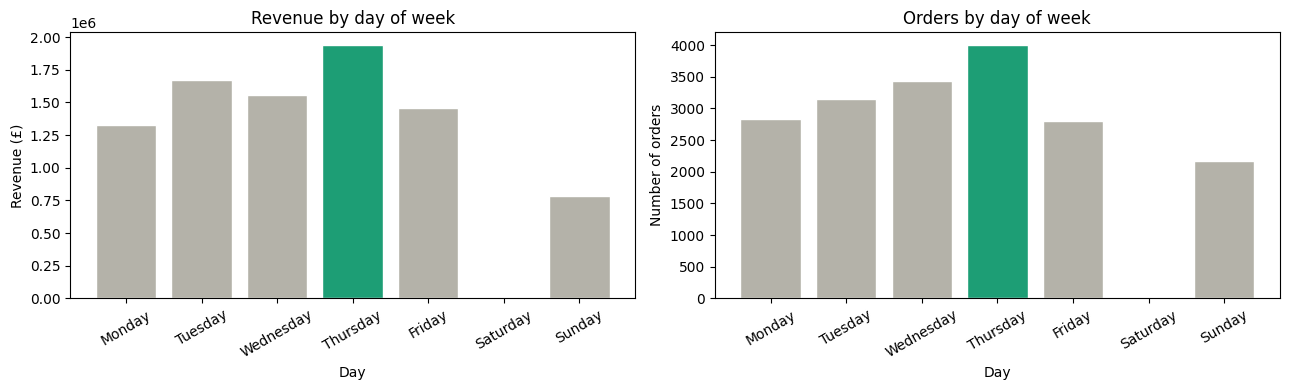

In [27]:
# highlighting the peak day automatically
peak_color  = "#1D9E75"   # teal for the highest bar
other_color = "#B4B2A9"   # gray for the rest

rev_colors = []

for v in day_revenue:
    if v == day_revenue.max():
        rev_colors.append(peak_color)
    else:
        rev_colors.append(other_color)

ord_colors = []

for v in day_orders:
    if v == day_orders.max():
        ord_colors.append(peak_color)
    else:
        ord_colors.append(other_color)


fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(day_revenue.index, day_revenue.values, color=rev_colors, edgecolor="white")
ax[0].set_title("Revenue by day of week")
ax[0].set_xlabel("Day")
ax[0].set_ylabel("Revenue (£)")
ax[0].tick_params(axis="x", rotation=30)

ax[1].bar(day_orders.index, day_orders.values, color=ord_colors, edgecolor="white")
ax[1].set_title("Orders by day of week")
ax[1].set_xlabel("Day")
ax[1].set_ylabel("Number of orders")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Thursday is the peak day for both revenue and orders, followed by Wednesday and Tuesday. Saturday records zero transactions and Sunday is near-silent — It is a common B2B business window for UK as their main business days reside from monday to friday (Likely for a work-life balance according to our research). Promotional campaigns,offers and discounts should be aligned to the Tuesday–Thursday window for maximum impact.**

In [28]:
sales_df["InvoiceNo"].value_counts()

,count
InvoiceNo,
576339,541
579196,532
580727,528
578270,441
573576,434
...,...
581458,1
569557,1
569550,1


In [29]:
# creating the pivot table — rows = days, columns = hours, values = unique orders
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot = (
    sales_df
    .groupby(["DayOfWeek", "Hours"])["InvoiceNo"]
    .nunique()
    .reset_index()
    .pivot(index="DayOfWeek", columns="Hours", values="InvoiceNo")
    .reindex(day_order)   # forces correct Mon→Sun order on y-axis
    .fillna(0)
    .astype(int)        # hours with no orders become 0 instead of NaN
)
pivot


Hours,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
DayOfWeek,,,,,,,,,,,,,,,
Monday,0,4,85,250,319,334,478,433,366,314,179,68,0,0,0
Tuesday,0,5,114,286,388,403,528,473,371,340,159,86,3,0,0
Wednesday,0,5,116,288,429,409,609,492,415,369,222,79,0,2,1
Thursday,1,9,119,292,438,368,583,475,438,418,307,244,164,132,16
Friday,0,6,120,265,405,363,461,395,355,250,115,62,2,9,1
Saturday,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Sunday,0,0,0,2,225,385,459,355,306,330,106,0,0,0,0


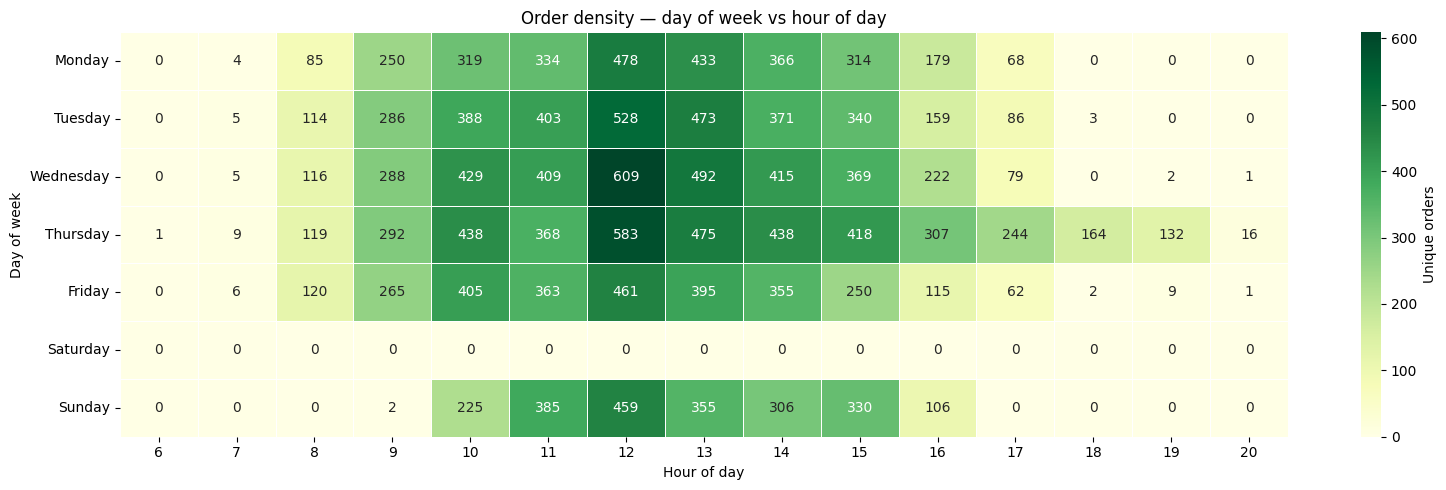

In [30]:
# plotting a heatmap to understand more clearly

plt.figure(figsize=(16, 5))

sns.heatmap(
    pivot,
    cmap="YlGn",          # light yellow = few orders, dark green = many orders
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt="d",
    cbar_kws={"label": "Unique orders"}
)

plt.title("Order density — day of week vs hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()

**The heatmap reveals that the single busiest window is Wednesday–Thursday between 11:00 and 13:00, peaking around midday. All weekday activity is tightly confined to 08:00–17:00, consistent with business purchasing hours. Saturday is completely silent with zero orders across all hours. Sunday shows a small but notable cluster of activity between 10:00–15:00 — likely a small segment of individual consumers or small bulk businesses or retail or late weekend order processing. The business should prioritise inventory readiness and customer support staffing during the Wednesday–Thursday midday window.**

In [31]:
# classify each day as weekday or weekend
sales_df["DayType"] = sales_df["DayOfWeek"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

# compare revenue and orders
daytype_summary = (
    sales_df
    .groupby("DayType")
    .agg(
        Revenue = ("Revenue", "sum"),
        Orders  = ("InvoiceNo", "nunique")
    )
    .reset_index()
)

daytype_summary["Revenue_%"] = (
    (daytype_summary["Revenue"] / daytype_summary["Revenue"].sum()) * 100
).round(2)

print(daytype_summary)

   DayType     Revenue  Orders  Revenue_%
0  Weekday  7957488.84   16234      91.08
1  Weekend   779738.80    2168       8.92


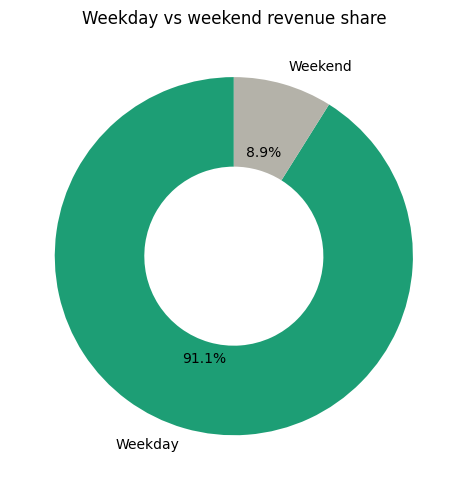

In [32]:
fig, ax = plt.subplots(figsize=(5, 5))

colors = ["#1D9E75", "#B4B2A9"]  # teal for weekday, gray for weekend

wedges, texts, autotexts = ax.pie(
    daytype_summary["Revenue_%"],
    labels=daytype_summary["DayType"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"width": 0.5}  # ← this is what makes it a donut instead of a pie
)

ax.set_title("Weekday vs weekend revenue share")
plt.tight_layout()
plt.show()

**91% of total revenue comes from weekdays, with only 9% from weekends. This pattern is consistent with a predominantly B2B customer base — Businesses place orders during working hours, not on weekends.**

#### Price distribution

In [33]:
sales_df["UnitPrice"].describe()

,UnitPrice
count,391150.000000
mean,2.874372
std,4.284738
min,0.040000
25%,1.250000
50%,1.950000
75%,3.750000
max,649.500000


In [34]:
# let's verify how much of the data falls within £20
under_20 = (sales_df["UnitPrice"] <= 20).sum()
total    = len(sales_df)
print(f"Rows under £20 : {under_20/total*100:.1f}%")

Rows under £20 : 99.8%


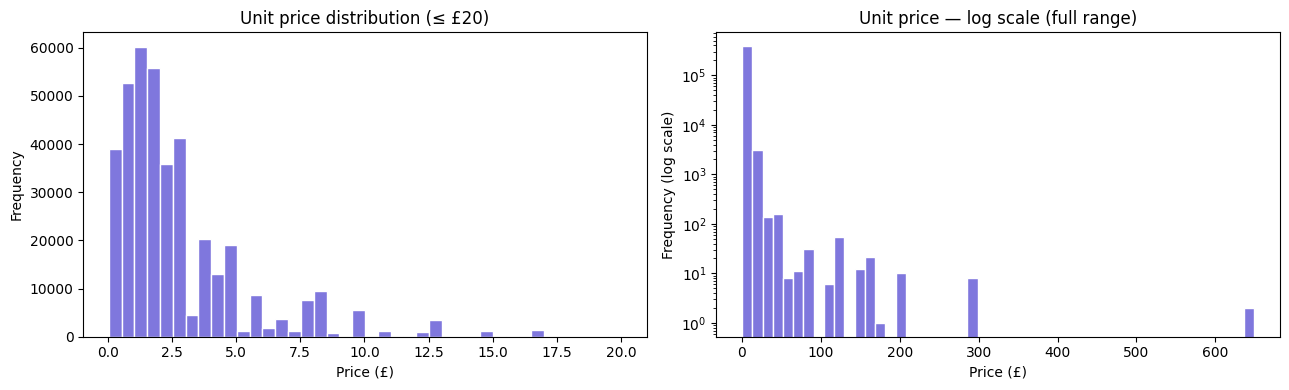

In [35]:
# price distribution

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# left chart — clipped at £20 to see the main distribution clearly
ax[0].hist(
    sales_df[sales_df["UnitPrice"] <= 20]["UnitPrice"],
    bins=40, color="#7F77DD", edgecolor="white"
)
ax[0].set_title("Unit price distribution (≤ £20)")
ax[0].set_xlabel("Price (£)")
ax[0].set_ylabel("Frequency")

# right chart — log scale to show full range including expensive items
ax[1].hist(
    sales_df[sales_df["UnitPrice"] > 0]["UnitPrice"],
    bins=50, color="#7F77DD", edgecolor="white", log=True
)
ax[1].set_title("Unit price — log scale (full range)")
ax[1].set_xlabel("Price (£)")
ax[1].set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()

In [36]:
# price band segmentation

bins   = [0, 1, 3, 5, 10, 20, float("inf")]
labels = ["<£1", "£1–3", "£3–5", "£5–10", "£10–20", "£20+"]

sales_df["PriceBand"] = pd.cut(
    sales_df["UnitPrice"],
    bins=bins,
    labels=labels
)

# revenue and order count per price band
price_band_summary = (
    sales_df
    .groupby("PriceBand", observed=True)
    .agg(
        Revenue = ("Revenue", "sum"),
        Orders  = ("InvoiceNo", "nunique"),
        Products= ("StockCode", "nunique")
    )
    .reset_index()
)

price_band_summary["Revenue_%"] = (
    (price_band_summary["Revenue"] / price_band_summary["Revenue"].sum()) * 100
).round(2)

print(price_band_summary)

  PriceBand     Revenue  Orders  Products  Revenue_%
0       <£1  1045963.87   13292      1250      11.97
1      £1–3  4360847.14   16879      2110      49.91
2      £3–5  1670547.85   13245       977      19.12
3     £5–10  1139435.58   11410       723      13.04
4    £10–20   413650.89    5253       247       4.73
5      £20+   106782.31     585        51       1.22


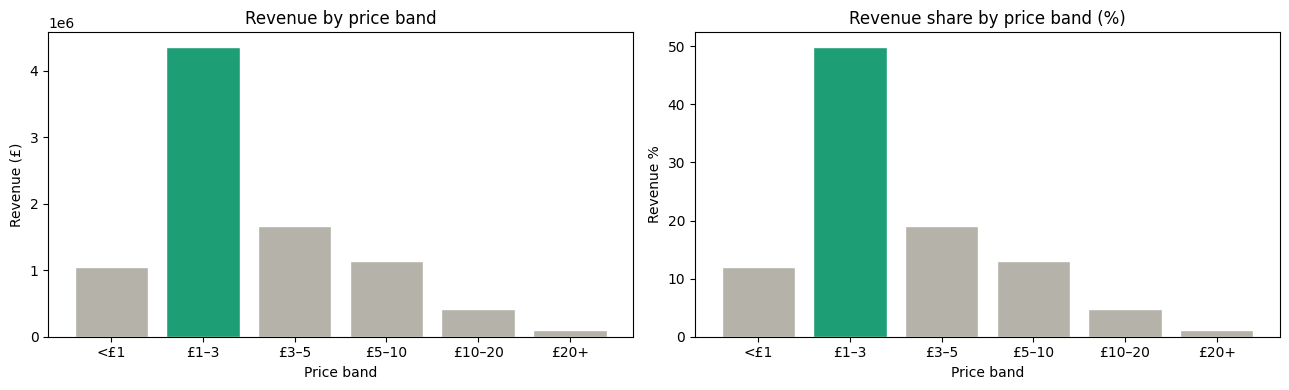

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# highlight the dominant band automatically
colors = ["#1D9E75" if b == "£1–3" else "#B4B2A9"
          for b in price_band_summary["PriceBand"]]

# left — revenue by price band
ax[0].bar(price_band_summary["PriceBand"],
          price_band_summary["Revenue"],
          color=colors, edgecolor="white")
ax[0].set_title("Revenue by price band")
ax[0].set_xlabel("Price band")
ax[0].set_ylabel("Revenue (£)")

# right — revenue percentage by price band
ax[1].bar(price_band_summary["PriceBand"],
          price_band_summary["Revenue_%"],
          color=colors, edgecolor="white")
ax[1].set_title("Revenue share by price band (%)")
ax[1].set_xlabel("Price band")
ax[1].set_ylabel("Revenue %")

plt.tight_layout()
plt.show()

**The £1–3 price band is the engine of this business — contributing nearly 50% of total revenue and generating the highest order volume. Combining the £1–5 range accounts for approximately 69% of all revenue, confirming this is a high-volume, low-price business model. Items priced above £20 contribute just 1.22% of revenue despite reaching up to £649, meaning premium pricing is not a meaningful revenue driver for this business.**

In [38]:
# correlation heatmap

corr_cols = ["Quantity", "UnitPrice", "Revenue", "Hours"]

corr_matrix = sales_df[corr_cols].corr()

print(corr_matrix.round(2))

           Quantity  UnitPrice  Revenue  Hours
Quantity       1.00      -0.02     0.92  -0.01
UnitPrice     -0.02       1.00     0.07  -0.00
Revenue        0.92       0.07     1.00  -0.01
Hours         -0.01      -0.00    -0.01   1.00


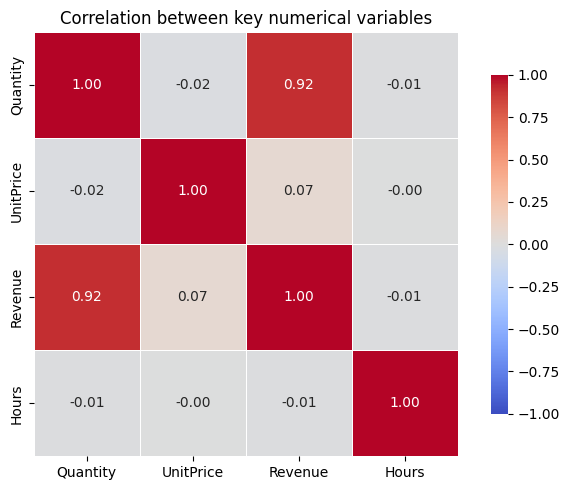

In [39]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,        # shows the numbers inside each cell
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # blue = negative, red = positive, white = zero
    center=0,          # white sits at 0 correlation
    vmin=-1, vmax=1,   # fix the scale between -1 and +1
    linewidths=0.5,
    square=True,       # makes each cell perfectly square
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation between key numerical variables")
plt.tight_layout()
plt.show()

**Quantity and Revenue show a very strong positive correlation (0.92), which is expected since revenue is a direct function of quantity sold. Notably, UnitPrice has almost no correlation with either Revenue (0.07) or Quantity (-0.02) — confirming that this is a highly volume-driven business where pricing plays a minimal role in determining overall revenue. Hour of day shows near-zero correlation with all variables, meaning purchase size and value are consistent throughout the working day.**

#### Country wise sales

In [40]:
country_sales = sales_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
country_sales

,Revenue
Country,
United Kingdom,7242855.32
Netherlands,283889.34
EIRE,257013.12
Germany,205381.15
France,183801.94
Australia,138103.81
Spain,55706.56
Switzerland,52441.95
Japan,37416.37


In [41]:
country_percent = (country_sales / sales_df["Revenue"].sum()) * 100
country_percent.head(10)

,Revenue
Country,
United Kingdom,82.896493
Netherlands,3.249192
EIRE,2.941587
Germany,2.350644
France,2.103664
Australia,1.580637
Spain,0.637577
Switzerland,0.600213
Japan,0.428241


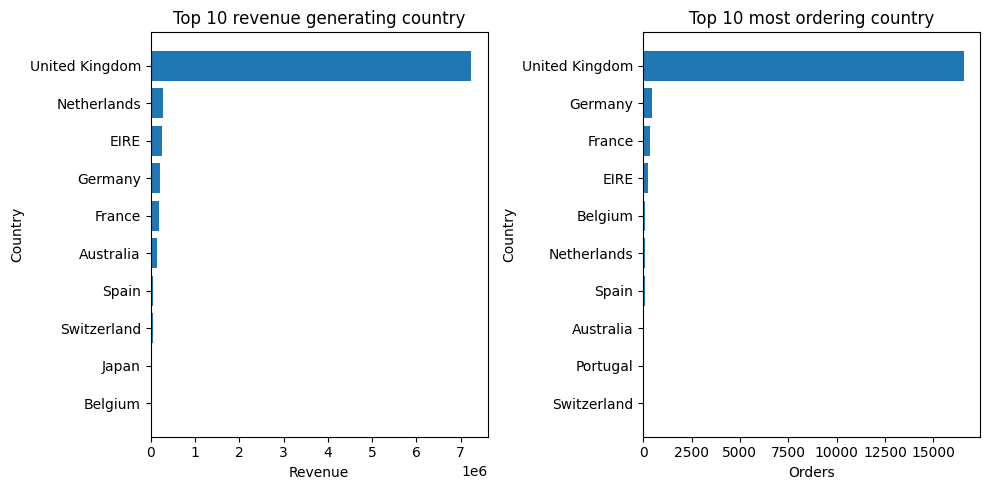

In [42]:
country_orders = sales_df.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].barh(country_sales.index, country_sales.values)
ax[0].set_title("Top 10 revenue generating country")
ax[0].set_xlabel("Revenue")
ax[0].set_ylabel("Country")
ax[0].invert_yaxis()

ax[1].barh(country_orders.index, country_orders.values)
ax[1].set_title("Top 10 most ordering country")
ax[1].set_xlabel("Orders")
ax[1].set_ylabel("Country")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

**UK is contributing 82% of the `Total Revenue` and The bar charts are clearly showing that this business is purely UK centric as the contributions of the other countries in revenue and orders are negligable. This also clears that the business have a dependency on UK market (that might be become a `Risk` factor in future) . So we are not persuing further country wise analysis**

#### Product Analysis

In [43]:
# Top 10 revenue generating products

product_sales = sales_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
product_sales

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
RABBIT NIGHT LIGHT,51251.24
CHILLI LIGHTS,46265.11


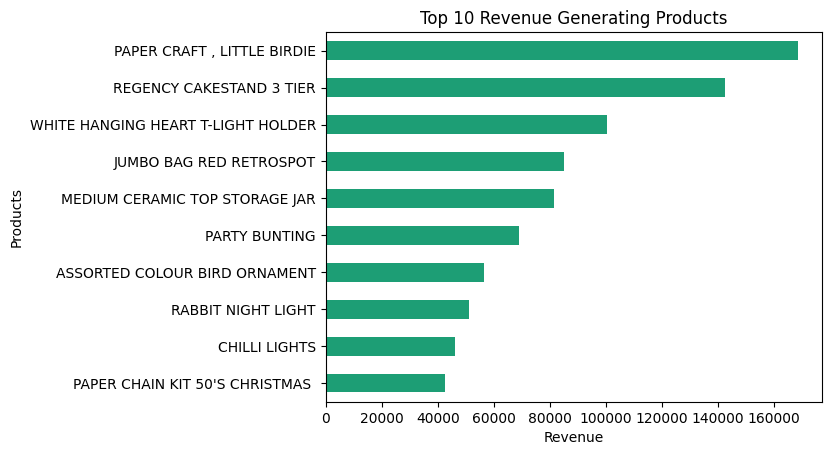

In [44]:
product_sales.sort_values().plot(
    kind="barh",
    color="#1D9E75"   # teal green (professional look)
)

plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Revenue")
plt.ylabel("Products")


plt.show()

**"REGENCY CAKESTAND 3 TIER" leads in gross revenue at £142,264, followed by "WHITE HANGING HEART T-LIGHT HOLDER" at £100,392. However, two entries — "PAPER CRAFT, LITTLE BIRDIE" (£168,469) and "MEDIUM CERAMIC TOP STORAGE JAR" (£77,183) — are artificial spikes caused by single bulk orders from customers 16446 and 12346, both of whom cancelled their orders immediately. These are not genuine revenue drivers and will be treated as outliers in subsequent analysis(as we will see at the next analysis).**

In [45]:
# Group by product and sum revenue
top_products = sales_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10).index.tolist()

# Filter dataframe for top 10 products
top_df = sales_df[sales_df["Description"].isin(top_products)]

In [46]:
monthly_product_revenue = top_df.groupby(["Month", "Description"])["Revenue"].sum().sort_values(ascending=False).reset_index()
monthly_product_revenue

,Month,Description,Revenue
0,12,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,1,MEDIUM CERAMIC TOP STORAGE JAR,77183.60
2,11,RABBIT NIGHT LIGHT,23190.41
3,12,REGENCY CAKESTAND 3 TIER,22113.78
4,11,PAPER CHAIN KIT 50'S CHRISTMAS,16109.51
...,...,...,...
96,12,MEDIUM CERAMIC TOP STORAGE JAR,203.51
97,4,CHILLI LIGHTS,46.00
98,5,PAPER CHAIN KIT 50'S CHRISTMAS,35.40
99,4,PAPER CHAIN KIT 50'S CHRISTMAS,29.50


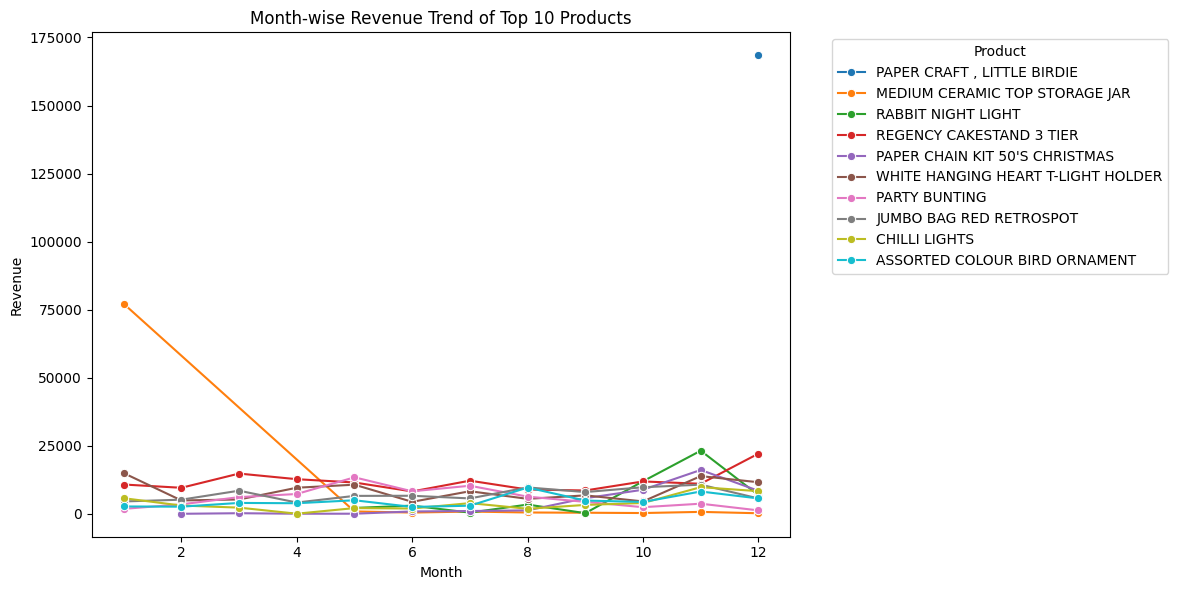

In [47]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_product_revenue,
    x="Month",
    y="Revenue",
    hue="Description",  # Legend automatically top 10 product names show kore
    marker="o"
)

plt.title("Month-wise Revenue Trend of Top 10 Products")
plt.xlabel("Month")
plt.ylabel("Revenue")

# Legend customization only
plt.legend(title="Product", bbox_to_anchor=(1.05, 1), loc='upper left')  # position adjust

plt.tight_layout()
plt.show()

In [48]:
anomaly_check = sales_df[sales_df["Description"]=="PAPER CRAFT , LITTLE BIRDIE"]
anomaly_check

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand
395869,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.6,9,12,2011,2011-12,09:15:00,9,Friday,Weekday,£1–3


In [49]:
sales_df[sales_df["CustomerID"]== 16446]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand
133206,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446,United Kingdom,1.65,18,5,2011,2011-05,09:52:00,9,Wednesday,Weekday,£1–3
133207,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446,United Kingdom,1.25,18,5,2011,2011-05,09:52:00,9,Wednesday,Weekday,£1–3
395869,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.60,9,12,2011,2011-12,09:15:00,9,Friday,Weekday,£1–3


In [50]:
products = [
    "MEDIUM CERAMIC TOP STORAGE JAR",
    "PAPER CRAFT , LITTLE BIRDIE",
    "RABBIT NIGHT LIGHT"
]
filtered_df = monthly_product_revenue[
    monthly_product_revenue["Description"].isin(products)
]

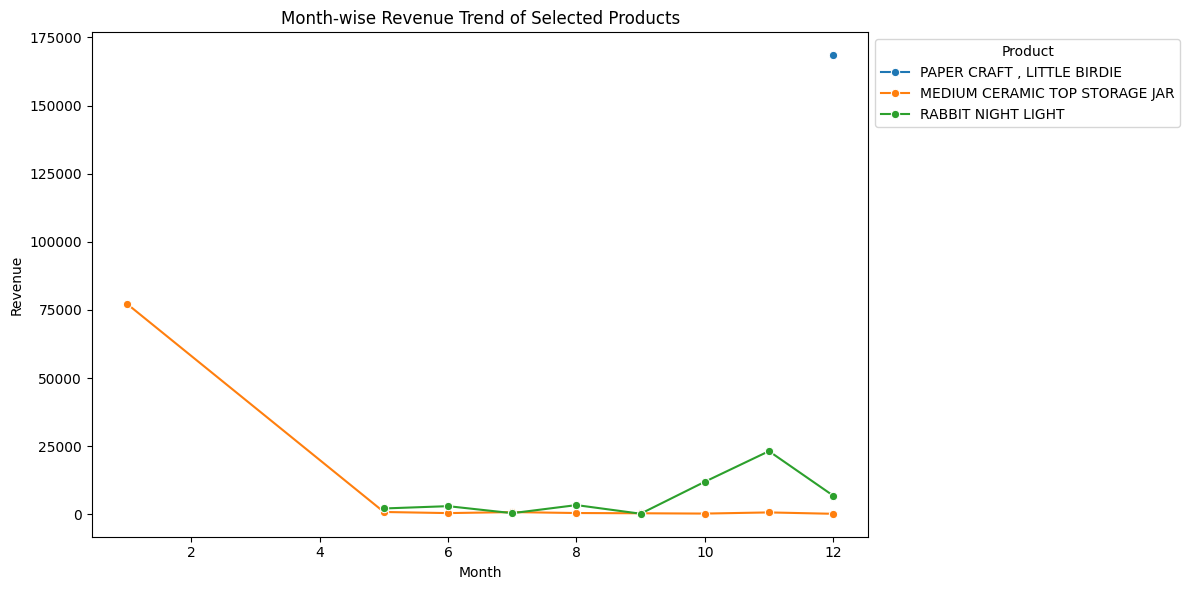

In [51]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=filtered_df,
    x="Month",
    y="Revenue",
    hue="Description",
    marker="o"
)

plt.title("Month-wise Revenue Trend of Selected Products")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend(title="Product", bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [52]:
weird_sales = sales_df[sales_df["Description"].isin(["MEDIUM CERAMIC TOP STORAGE JAR", "RABBIT NIGHT LIGHT"])]
weird_sales

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand
36974,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.60,18,1,2011,2011-01,10:01:00,10,Tuesday,Weekday,£1–3
125185,552654,23084,RABBIT NIGHT LIGHT,2,2011-05-10 14:20:00,2.08,15756,United Kingdom,4.16,10,5,2011,2011-05,14:20:00,14,Tuesday,Weekday,£1–3
125720,552724,23084,RABBIT NIGHT LIGHT,6,2011-05-11 10:29:00,2.08,13418,United Kingdom,12.48,11,5,2011,2011-05,10:29:00,10,Wednesday,Weekday,£1–3
126084,552811,23084,RABBIT NIGHT LIGHT,24,2011-05-11 12:43:00,1.79,17677,United Kingdom,42.96,11,5,2011,2011-05,12:43:00,12,Wednesday,Weekday,£1–3
126133,552816,23084,RABBIT NIGHT LIGHT,1,2011-05-11 12:47:00,2.08,15521,United Kingdom,2.08,11,5,2011,2011-05,12:47:00,12,Wednesday,Weekday,£1–3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395912,581494,23084,RABBIT NIGHT LIGHT,24,2011-12-09 10:13:00,1.79,12518,Germany,42.96,9,12,2011,2011-12,10:13:00,10,Friday,Weekday,£1–3
395962,581496,23084,RABBIT NIGHT LIGHT,18,2011-12-09 10:20:00,2.08,16558,United Kingdom,37.44,9,12,2011,2011-12,10:20:00,10,Friday,Weekday,£1–3
396064,581538,23084,RABBIT NIGHT LIGHT,2,2011-12-09 11:34:00,2.08,14446,United Kingdom,4.16,9,12,2011,2011-12,11:34:00,11,Friday,Weekday,£1–3
396252,581579,23084,RABBIT NIGHT LIGHT,24,2011-12-09 12:19:00,1.79,17581,United Kingdom,42.96,9,12,2011,2011-12,12:19:00,12,Friday,Weekday,£1–3


In [53]:
sales_df[sales_df["Description"]=="MEDIUM CERAMIC TOP STORAGE JAR"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand
36974,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.60,18,1,2011,2011-01,10:01:00,10,Tuesday,Weekday,£1–3
127281,552882,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,2011-05-12 10:10:00,1.04,14646,Netherlands,99.84,12,5,2011,2011-05,10:10:00,10,Thursday,Weekday,£1–3
127699,552953,23166,MEDIUM CERAMIC TOP STORAGE JAR,4,2011-05-12 12:11:00,1.25,16745,United Kingdom,5.00,12,5,2011,2011-05,12:11:00,12,Thursday,Weekday,£1–3
128216,553005,23166,MEDIUM CERAMIC TOP STORAGE JAR,5,2011-05-12 16:29:00,1.25,14651,United Kingdom,6.25,12,5,2011,2011-05,16:29:00,16,Thursday,Weekday,£1–3
128366,553009,23166,MEDIUM CERAMIC TOP STORAGE JAR,3,2011-05-12 16:52:00,1.25,13601,United Kingdom,3.75,12,5,2011,2011-05,16:52:00,16,Thursday,Weekday,£1–3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386765,580665,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,2011-12-05 14:06:00,1.04,16684,United Kingdom,99.84,5,12,2011,2011-12,14:06:00,14,Monday,Weekday,£1–3
390304,580956,23166,MEDIUM CERAMIC TOP STORAGE JAR,1,2011-12-06 14:23:00,1.25,17841,United Kingdom,1.25,6,12,2011,2011-12,14:23:00,14,Tuesday,Weekday,£1–3
390965,580997,23166,MEDIUM CERAMIC TOP STORAGE JAR,4,2011-12-06 17:23:00,1.25,15023,United Kingdom,5.00,6,12,2011,2011-12,17:23:00,17,Tuesday,Weekday,£1–3
391656,581108,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,2011-12-07 12:16:00,1.25,15984,United Kingdom,2.50,7,12,2011,2011-12,12:16:00,12,Wednesday,Weekday,£1–3


In [54]:
sales_df.sort_values("Revenue", ascending = False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand
395869,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.60,9,12,2011,2011-12,09:15:00,9,Friday,Weekday,£1–3
36974,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.60,18,1,2011,2011-01,10:01:00,10,Tuesday,Weekday,£1–3
154774,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098,United Kingdom,38970.00,10,6,2011,2011-06,15:28:00,15,Friday,Weekday,£20+
247699,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450,United Kingdom,7144.72,20,9,2011,2011-09,11:05:00,11,Tuesday,Weekday,£5–10
109169,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749,United Kingdom,6539.40,18,4,2011,2011-04,13:20:00,13,Monday,Weekday,£1–3
32599,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749,United Kingdom,6539.40,11,1,2011,2011-01,12:55:00,12,Tuesday,Weekday,£1–3
306843,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646,Netherlands,4992.00,27,10,2011,2011-10,12:11:00,12,Thursday,Weekday,£1–3
32597,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-01-11 12:55:00,2.55,15749,United Kingdom,4921.50,11,1,2011,2011-01,12:55:00,12,Tuesday,Weekday,£1–3
109165,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-04-18 13:20:00,2.40,15749,United Kingdom,4632.00,18,4,2011,2011-04,13:20:00,13,Monday,Weekday,£1–3
32660,540818,48185,DOORMAT FAIRY CAKE,670,2011-01-11 12:57:00,6.75,15749,United Kingdom,4522.50,11,1,2011,2011-01,12:57:00,12,Tuesday,Weekday,£5–10


In [55]:
return_df.sort_values("ReturnValue", ascending = True).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,ReturnValue,Day,Month,Year,MonthYear,Time,DayOfWeek
8533,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446,United Kingdom,-168469.60,9,12,2011,2011-12,09:27:00,Friday
969,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom,-77183.60,18,1,2011,2011-01,10:17:00,Tuesday
2713,C550456,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3114,2011-04-18 13:08:00,2.10,15749,United Kingdom,-6539.40,18,4,2011,2011-04,13:08:00,Monday
2711,C550456,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1930,2011-04-18 13:08:00,2.55,15749,United Kingdom,-4921.50,18,4,2011,2011-04,13:08:00,Monday
2709,C550456,48185,DOORMAT FAIRY CAKE,-670,2011-04-18 13:08:00,6.75,15749,United Kingdom,-4522.50,18,4,2011,2011-04,13:08:00,Monday
5708,C567527,23113,PANTRY CHOPPING BOARD,-756,2011-09-21 09:16:00,5.06,17450,United Kingdom,-3825.36,21,9,2011,2011-09,09:16:00,Wednesday
2712,C550456,21175,GIN + TONIC DIET METAL SIGN,-2000,2011-04-18 13:08:00,1.85,15749,United Kingdom,-3700.00,18,4,2011,2011-04,13:08:00,Monday
2710,C550456,47566B,TEA TIME PARTY BUNTING,-1300,2011-04-18 13:08:00,2.55,15749,United Kingdom,-3315.00,18,4,2011,2011-04,13:08:00,Monday
5315,C565044,22191,IVORY DINER WALL CLOCK,-318,2011-08-31 17:02:00,7.65,12931,United Kingdom,-2432.70,31,8,2011,2011-08,17:02:00,Wednesday
6575,C570556,22273,FELTCRAFT DOLL MOLLY,-720,2011-10-11 11:10:00,2.55,16029,United Kingdom,-1836.00,11,10,2011,2011-10,11:10:00,Tuesday


In [56]:
sales_df[sales_df["CustomerID"]==16446]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand
133206,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446,United Kingdom,1.65,18,5,2011,2011-05,09:52:00,9,Wednesday,Weekday,£1–3
133207,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446,United Kingdom,1.25,18,5,2011,2011-05,09:52:00,9,Wednesday,Weekday,£1–3
395869,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.60,9,12,2011,2011-12,09:15:00,9,Friday,Weekday,£1–3


In [57]:
sales_df[sales_df["CustomerID"]==12346]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand
36974,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.6,18,1,2011,2011-01,10:01:00,10,Tuesday,Weekday,£1–3


**We can clearly see that the two customer `16446` and `12346` ordered an unusual bulk quantity and returned within minutes like cancellation and didn't placed any other valuable orders. So, we are removing these two customers (acts as an `outlier`) from the `sales_df` to properly undergo further analysis process (like Segmentation) or these will disrupt our upcoming analysis processes**

In [58]:
sales_df = sales_df[~sales_df["CustomerID"].isin([16446, 12346])]

sales_df.sort_values("Revenue", ascending = False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand
154774,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098,United Kingdom,38970.00,10,6,2011,2011-06,15:28:00,15,Friday,Weekday,£20+
247699,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450,United Kingdom,7144.72,20,9,2011,2011-09,11:05:00,11,Tuesday,Weekday,£5–10
109169,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749,United Kingdom,6539.40,18,4,2011,2011-04,13:20:00,13,Monday,Weekday,£1–3
32599,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749,United Kingdom,6539.40,11,1,2011,2011-01,12:55:00,12,Tuesday,Weekday,£1–3
306843,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646,Netherlands,4992.00,27,10,2011,2011-10,12:11:00,12,Thursday,Weekday,£1–3
32597,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-01-11 12:55:00,2.55,15749,United Kingdom,4921.50,11,1,2011,2011-01,12:55:00,12,Tuesday,Weekday,£1–3
109165,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-04-18 13:20:00,2.40,15749,United Kingdom,4632.00,18,4,2011,2011-04,13:20:00,13,Monday,Weekday,£1–3
32660,540818,48185,DOORMAT FAIRY CAKE,670,2011-01-11 12:57:00,6.75,15749,United Kingdom,4522.50,11,1,2011,2011-01,12:57:00,12,Tuesday,Weekday,£5–10
170869,558526,23173,REGENCY TEAPOT ROSES,540,2011-06-30 11:01:00,8.15,17949,United Kingdom,4401.00,30,6,2011,2011-06,11:01:00,11,Thursday,Weekday,£5–10
109167,550461,48185,DOORMAT FAIRY CAKE,670,2011-04-18 13:20:00,6.35,15749,United Kingdom,4254.50,18,4,2011,2011-04,13:20:00,13,Monday,Weekday,£5–10


In [59]:
top_products_qty = (
    sales_df.groupby("Description")
    .agg({
        "Quantity": "sum",
        "Revenue": "sum"
    })
    .sort_values("Quantity", ascending=False)
    .head(10))
top_products_qty

,Quantity,Revenue
Description,,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319,13558.41
JUMBO BAG RED RETROSPOT,46078,85040.54
WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10
ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03
PACK OF 72 RETROSPOT CAKE CASES,33670,16381.88
POPCORN HOLDER,30919,23417.51
RABBIT NIGHT LIGHT,27153,51251.24
MINI PAINT SET VINTAGE,26076,16039.24
PACK OF 12 LONDON TISSUES,25329,7261.77


As It is a highly volumn driven business, the products, ordered in high quantities are the main key drivers."WORLD WAR 2 GLIDERS ASSTD DESIGNS","JUMBO BAG RED RETROSPOT" and "WHITE HANGING HEART T-LIGHT HOLDER" are the top 3 quantity sold product.Among these the `WHITE HANGING HEART T-LIGHT HOLDER` is the 3rd most high quantity order and also is the 3rd highest revenue generating product following with `JUMBO BAG RED RETROSPOT`, can be considered as the `Key product`

#### Splitting Dataset

In [60]:
# step 1 — classify each invoice by total quantity
invoice_type = (
    sales_df
    .groupby("InvoiceNo")["Quantity"]
    .sum()
    .reset_index()
)
invoice_type["Order_Type"] = invoice_type["Quantity"].apply(
    lambda x: "Wholesale" if x > 300 else "Retail"
)

# step 2 — merge type back into main dataframe
sales_df = sales_df.merge(
    invoice_type[["InvoiceNo", "Order_Type"]],
    on="InvoiceNo",
    how="left"
)

# step 3 — split with same variable names as before
sales_retail_df    = sales_df[sales_df["Order_Type"] == "Retail"].copy()
sales_wholesale_df = sales_df[sales_df["Order_Type"] == "Wholesale"].copy()

print("Retail rows    :", len(sales_retail_df))
print("Wholesale rows :", len(sales_wholesale_df))

Retail rows    : 236133
Wholesale rows : 155013


**We are splitting the dataset into two parts as Retail/small bulk retailers and Wholesale/bulk retailers because the customer behaviour, product behaviour and segmentation strategies are different for small retail bulk orders and wholesale bulk orders**

In [61]:
# Total orders
total_orders = sales_df["InvoiceNo"].nunique()

# Retail orders
retail_orders = sales_retail_df["InvoiceNo"].nunique()

# Wholesale orders
wholesale_orders = sales_wholesale_df["InvoiceNo"].nunique()

# Percent contribution
retail_pct = (retail_orders / total_orders) * 100
wholesale_pct = (wholesale_orders / total_orders) * 100

print(f"Retail Contribution: {retail_pct:.2f}%")
print(f"Wholesale Contribution: {wholesale_pct:.2f}%")

Retail Contribution: 76.07%
Wholesale Contribution: 23.93%


**76% of all orders are retail and 24% are wholesale — but the revenue split tells a different story. Wholesale customers, despite being fewer in number, generate disproportionately higher revenue per order due to bulk purchasing. This dual-channel structure means the business must serve two very different customer types simultaneously: individual retail buyers who order frequently in small quantities, and wholesale buyers who order less often but in large volumes.**

### 3.2 Retail Sales Analysis

In [62]:
sales_retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand,Order_Type
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,1,12,2010,2010-12,08:26:00,8,Wednesday,Weekday,£1–3,Retail
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,12,2010,2010-12,08:26:00,8,Wednesday,Weekday,£3–5,Retail
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,1,12,2010,2010-12,08:26:00,8,Wednesday,Weekday,£1–3,Retail
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,12,2010,2010-12,08:26:00,8,Wednesday,Weekday,£3–5,Retail
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,12,2010,2010-12,08:26:00,8,Wednesday,Weekday,£3–5,Retail


In [63]:
sales_retail_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Day,Month,Year,Hours
count,236133.000000,236133,236133.000000,236133.000000,236133.000000,236133.00000,236133.000000,236133.000000,236133.000000
mean,7.379447,2011-07-03 19:16:57.503779584,3.068348,15465.082441,15.124532,14.92132,7.539848,2010.920989,12.778091
min,1.000000,2010-12-01 08:26:00,0.040000,12347.000000,0.060000,1.00000,1.000000,2010.000000,6.000000
25%,2.000000,2011-03-29 12:31:00,1.250000,14092.000000,3.750000,7.00000,5.000000,2011.000000,11.000000
50%,4.000000,2011-07-14 17:40:00,2.080000,15453.000000,9.950000,14.00000,8.000000,2011.000000,13.000000
75%,10.000000,2011-10-19 16:05:00,3.750000,16931.000000,17.400000,22.00000,11.000000,2011.000000,14.000000
max,300.000000,2011-12-09 12:50:00,649.500000,18287.000000,38970.000000,31.00000,12.000000,2011.000000,20.000000
std,11.844976,NaN,4.719078,1690.870215,84.995440,8.69099,3.479502,0.269756,2.269251


In [64]:
# observing the KPIs

summary_retail = {
    "Total Retail Revenue": sales_retail_df["Revenue"].sum(),
    "Total Retail Orders": sales_retail_df["InvoiceNo"].nunique(),
    "Total Retail Products": sales_retail_df["StockCode"].nunique(),
    "Total Retail Quantity Sold": sales_retail_df["Quantity"].sum(),
    "Total Retail Customers": sales_retail_df["CustomerID"].nunique()
}

sales_retail_summary_df = pd.DataFrame(summary_retail, index=["Value"])
sales_retail_summary_df

,Total Retail Revenue,Total Retail Orders,Total Retail Products,Total Retail Quantity Sold,Total Retail Customers
Value,3571401.12,13997,3569,1742531,3900


#### Time Series Analysis Retail

In [65]:
monthly_retail_sales = (
    sales_retail_df
    .groupby("MonthYear")["Revenue"]
    .sum()
    .reset_index()
)
monthly_retail_sales.sort_values("Revenue", ascending=False)

,MonthYear,Revenue
11,2011-11,498452.85
10,2011-10,363649.64
9,2011-09,326100.62
5,2011-05,315105.56
6,2011-06,295647.05
0,2010-12,284677.22
3,2011-03,255446.98
7,2011-07,242975.52
8,2011-08,227612.39
4,2011-04,217374.95


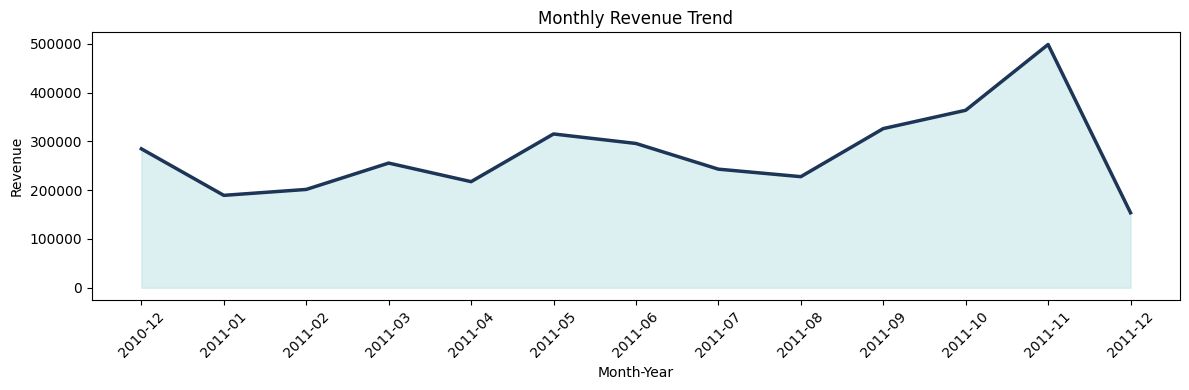

In [66]:
plt.figure(figsize=(12,4))

# numeric x-axis
x = range(len(monthly_retail_sales))

# Dark line
sns.lineplot(
    x=x,
    y=monthly_retail_sales["Revenue"],
    color="#1D3557",
    linewidth=2.5
)

# Light area
plt.fill_between(
    x,
    monthly_retail_sales["Revenue"],
    color="#A8DADC",
    alpha=0.4
)

# Fix labels
plt.xticks(x, monthly_retail_sales["MonthYear"], rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month-Year")
plt.ylabel("Revenue")


plt.tight_layout()
plt.show()

**Retail revenue follows a clear seasonal pattern, peaking sharply in November 2011 at £498,452 — nearly 40% higher than the next best month (October, £363,649). The summer months (June–August) show relatively flat revenue, while the Q4 surge is unmistakable. Retail customers appear highly seasonal, driven by gifting occasions and the festivals shopping cycle. This seasonality should be used to plan targeted promotions in September–October to capture early holiday buyers.**

In [67]:
# creating the pivot table — rows = days, columns = hours, values = unique orders
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot_retail = (
    sales_retail_df
    .groupby(["DayOfWeek", "Hours"])["InvoiceNo"]
    .nunique()
    .reset_index()
    .pivot(index="DayOfWeek", columns="Hours", values="InvoiceNo")
    .reindex(day_order)   # forces correct Mon→Sun order on y-axis
    .fillna(0)
    .astype(int)        # hours with no orders become 0 instead of NaN
)
pivot_retail

Hours,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
DayOfWeek,,,,,,,,,,,,,,,
Monday,0,3,57,181,218,262,353,316,282,240,141,51,0,0,0
Tuesday,0,4,82,208,270,291,396,359,277,260,128,73,3,0,0
Wednesday,0,3,91,221,303,287,479,378,307,280,180,63,0,2,0
Thursday,1,6,95,207,318,281,440,375,334,324,244,192,129,117,10
Friday,0,2,96,199,305,272,332,301,276,192,90,49,2,9,1
Saturday,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Sunday,0,0,0,2,193,315,372,271,250,257,90,0,0,0,0


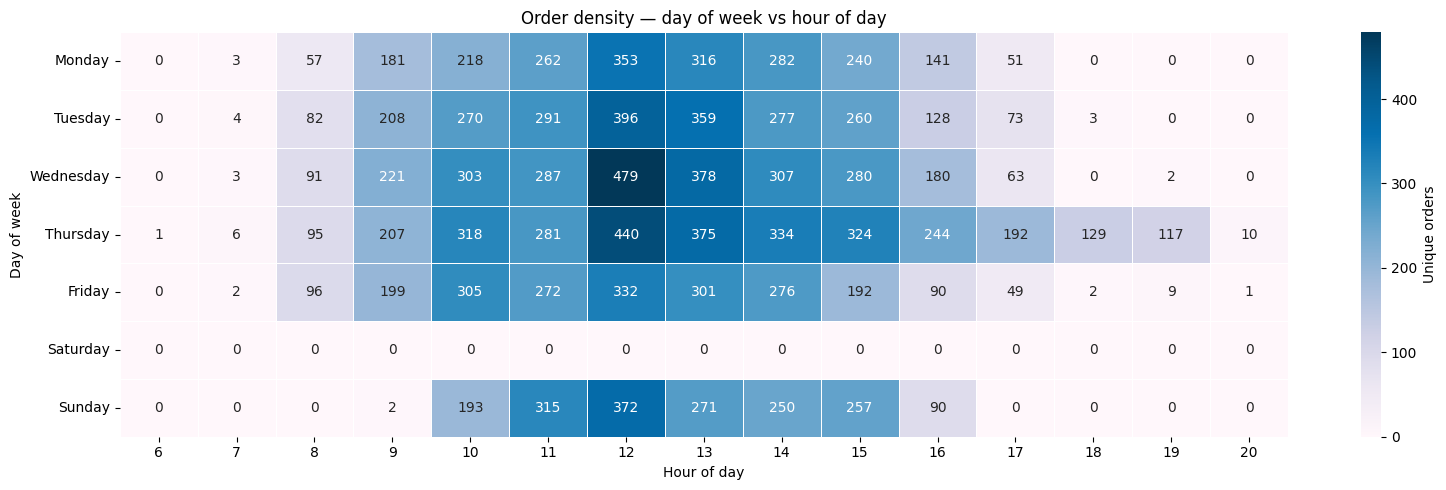

In [68]:
# plotting a heatmap to understand more clearly

plt.figure(figsize=(16, 5))

sns.heatmap(
    pivot_retail,
    cmap="PuBu",          # light yellow = few orders, dark green = many orders
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt="d",
    cbar_kws={"label": "Unique orders"}
)

plt.title("Order density — day of week vs hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()

**Retail ordering behaviour mirrors the overall pattern: peak activity falls on Wednesday–Thursday between 11:00 and 13:00. The retail heatmap is slightly less concentrated than the combined heatmap, suggesting that wholesale orders contribute more to the midday peaks. Sunday retail activity is modest but visible.**

In [69]:
daytype_summary_retail = (
    sales_retail_df
    .groupby("DayType")
    .agg(
        Revenue = ("Revenue", "sum"),
        Orders  = ("InvoiceNo", "nunique")
    )
    .reset_index()
)

daytype_summary_retail["Revenue_%"] = (
    (daytype_summary_retail["Revenue"] / daytype_summary_retail["Revenue"].sum()) * 100
).round(2)

print(daytype_summary_retail)

   DayType     Revenue  Orders  Revenue_%
0  Weekday  3140699.13   12247      87.94
1  Weekend   430701.99    1750      12.06


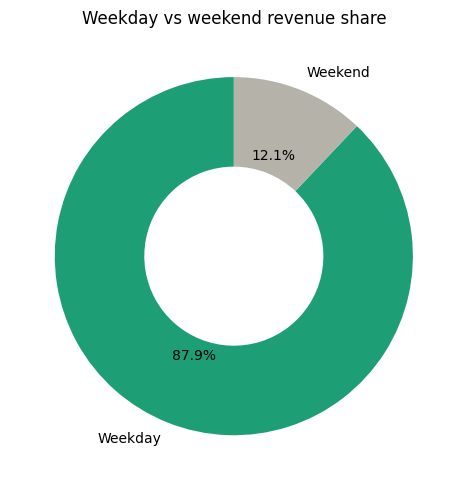

In [70]:
fig, ax = plt.subplots(figsize=(5, 5))

colors = ["#1D9E75", "#B4B2A9"]  # teal for weekday, gray for weekend

wedges, texts, autotexts = ax.pie(
    daytype_summary_retail["Revenue_%"],
    labels=daytype_summary_retail["DayType"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"width": 0.5}  # ← this is what makes it a donut instead of a pie
)

ax.set_title("Weekday vs weekend revenue share")
plt.tight_layout()
plt.show()

#### Product Analysis

In [71]:
retail_product_sales = sales_retail_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
retail_product_sales

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,72832.60
WHITE HANGING HEART T-LIGHT HOLDER,44747.20
PARTY BUNTING,41471.40
PICNIC BASKET WICKER 60 PIECES,39619.50
JUMBO BAG RED RETROSPOT,26587.03
ASSORTED COLOUR BIRD ORNAMENT,25259.62
DOORMAT KEEP CALM AND COME IN,22044.61
RABBIT NIGHT LIGHT,20894.95
CHILLI LIGHTS,20424.32


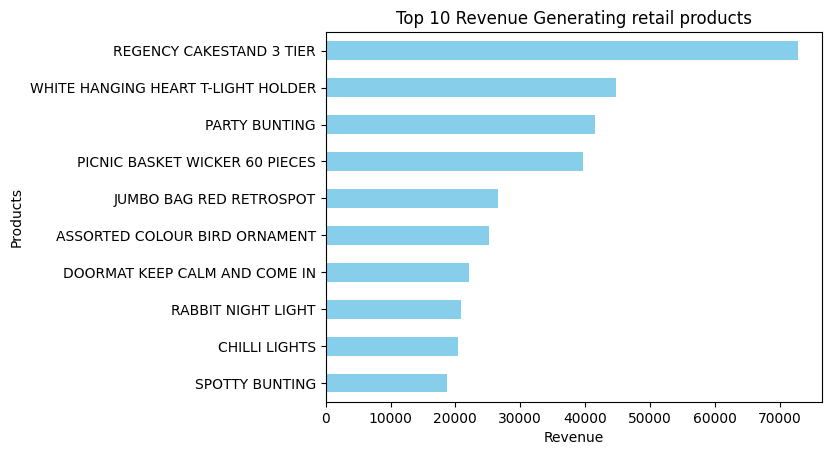

In [72]:
retail_product_sales.sort_values().plot(kind="barh", color="skyblue")

plt.title("Top 10 Revenue Generating retail products")
plt.xlabel("Revenue")
plt.ylabel("Products")

plt.show()

**"REGENCY CAKESTAND 3 TIER" is the undisputed retail star at £72,832, nearly double the second-ranked product. The top 10 retail products are predominantly homeware, gifting, and decorative items — consistent with a consumer-facing gifting retailer. Notably, high-revenue products do not always top the quantity chart: "WHITE HANGING HEART T-LIGHT HOLDER" sells the most units (16,288) but ranks second in revenue, indicating a lower unit price but extremely high demand volume.**

In [73]:
retail_Quantity = (
    sales_retail_df.groupby("Description")
    .agg({
        "Quantity" : "sum",
        "Revenue" : "sum"
    })
    .rename(columns= {
        "Quantity" : "Total_Quantity"
    }).sort_values("Total_Quantity", ascending=False).head(10))
retail_Quantity

,Total_Quantity,Revenue
Description,,
WHITE HANGING HEART T-LIGHT HOLDER,16288,44747.20
ASSORTED COLOUR BIRD ORNAMENT,15226,25259.62
JUMBO BAG RED RETROSPOT,13560,26587.03
VICTORIAN GLASS HANGING T-LIGHT,12189,16274.77
RABBIT NIGHT LIGHT,11197,20894.95
PARTY BUNTING,9100,41471.40
ANTIQUE SILVER T-LIGHT GLASS,8189,9524.89
WORLD WAR 2 GLIDERS ASSTD DESIGNS,7934,2300.86
POPCORN HOLDER,7653,6076.05


In [74]:
retail_orders = (
    sales_retail_df.groupby("Description")
    .agg({
        "InvoiceNo" : "nunique",
        "Revenue" : "sum"
    })
    .rename(columns= {
        "InvoiceNo" : "Total_Orders"
    }).sort_values("Total_Orders", ascending=False).head(10))
retail_orders

,Total_Orders,Revenue
Description,,
WHITE HANGING HEART T-LIGHT HOLDER,1433,44747.20
REGENCY CAKESTAND 3 TIER,1123,72832.60
JUMBO BAG RED RETROSPOT,980,26587.03
PARTY BUNTING,965,41471.40
ASSORTED COLOUR BIRD ORNAMENT,921,25259.62
SET OF 3 CAKE TINS PANTRY DESIGN,756,13478.27
LUNCH BAG RED RETROSPOT,736,10127.00
REX CASH+CARRY JUMBO SHOPPER,713,1384.15
HEART OF WICKER SMALL,678,11109.95


In [75]:
expensive_retail_product = (
    sales_retail_df.groupby("Description")
    .agg({
        "UnitPrice": "mean",
        "InvoiceNo": "nunique"
    })
    .rename(columns={
        "UnitPrice": "AvgPrice",
        "InvoiceNo": "TotalOrders"
    })
    .sort_values("AvgPrice", ascending=False)
    .head(10)
)

expensive_retail_product

,AvgPrice,TotalOrders
Description,,
PICNIC BASKET WICKER 60 PIECES,649.500000,2
RUSTIC SEVENTEEN DRAWER SIDEBOARD,159.000000,20
REGENCY MIRROR WITH SHUTTERS,157.000000,5
VINTAGE BLUE KITCHEN CABINET,156.875000,16
VINTAGE RED KITCHEN CABINET,144.629630,27
CHEST NATURAL WOOD 20 DRAWERS,118.571429,7
LOVE SEAT ANTIQUE WHITE METAL,112.500000,32
VINTAGE POST OFFICE CABINET,79.950000,1
SCHOOL DESK AND CHAIR,65.000000,4


 ***Retail Product Insights***

**Top products by quantity sold, orders placed, and average price reveal three distinct product archetypes:**

**1. High-volume, low-price workhorses (quantity leaders)**
"WHITE HANGING HEART T-LIGHT HOLDER" dominates on all three fronts — highest units sold (16,288), most orders (1,433), and strong revenue (£44,747). This is the business's most reliable retail product. "JUMBO BAG RED RETROSPOT" and "PARTY BUNTING" also appear in both the quantity and orders top 10, confirming they are consistent, broad-demand products.

However, several high-quantity products generate surprisingly low revenue:
- "WORLD WAR 2 GLIDERS ASSTD DESIGNS" — 7,934 units sold but only £2,300 revenue (avg price ~£0.29)
- "PACK OF 72 RETROSPOT CAKE CASES" — 7,358 units but only £3,981 revenue (avg price ~£0.54)
- "POPCORN HOLDER" — 7,653 units but £3,607 revenue (avg price ~£0.47)

These are ultra-cheap fillers — they inflate order counts and quantity metrics but contribute almost nothing to the bottom line.

**2. High-order, high-revenue stars (orders leaders)**
"REGENCY CAKESTAND 3 TIER" is the standout here — only 1,123 orders but £72,832 revenue, meaning customers pay significantly more per unit (avg ~£64.84). It doesn't appear in the quantity top 10 at all, confirming it is a low-volume, high-value product. Similarly, "NATURAL SLATE HEART CHALKBOARD" (672 orders, £13,120) and "HEART OF WICKER SMALL" (678 orders, £11,109) punch above their weight in revenue relative to volume.

**3. Premium products (avg price leaders) — niche but low demand**
"PICNIC BASKET WICKER 60 PIECES" at £649.50 is the most expensive retail product — but with only 2 orders, it is effectively a one-off. "RUSTIC SEVENTEEN DRAWER SIDEBOARD" (£159, 20 orders) and "VINTAGE BLUE/RED KITCHEN CABINET" (~£145–157, 16–27 orders) show that the premium furniture-style range has a small but real customer base. These products will never be volume drivers, but their high margins make even a handful of sales worthwhile.

**Overall verdict:**
The retail product range is clearly a gifting and homeware catalogue built on a high-volume, low-price core. The business's best all-round performer is "WHITE HANGING HEART T-LIGHT HOLDER" — strong across quantity, orders, and revenue. The biggest opportunity lies in growing the mid-tier products like "REGENCY CAKESTAND 3 TIER" that already show high revenue-per-order.

#### Customer Analysis

In [76]:
avg_revenue_per_customer = (sales_retail_df.groupby("CustomerID")["Revenue"].sum().mean())
avg_revenue_per_customer

np.float64(915.7438769230769)

In [77]:
avg_orders_per_customer = (sales_retail_df.groupby("CustomerID")["InvoiceNo"].nunique().mean())
avg_orders_per_customer

np.float64(3.588974358974359)

In [78]:
# basket size analysis (retail only)

basket = (
    sales_retail_df
    .groupby("InvoiceNo")
    .agg(
        Items        = ("StockCode", "nunique"),
        TotalQty     = ("Quantity", "sum"),
        OrderRevenue = ("Revenue", "sum")
    )
)

basket

,Items,TotalQty,OrderRevenue
InvoiceNo,,,
536365,7,40,139.12
536366,2,12,22.20
536367,12,83,278.73
536368,4,15,70.05
536369,1,3,17.85
...,...,...,...
581583,2,76,124.60
581584,2,120,140.64
581585,21,278,329.05


In [79]:
basket.describe().round(2)

,Items,TotalQty,OrderRevenue
count,13997.00,13997.00,13997.00
mean,16.64,124.49,255.15
std,16.04,79.64,368.07
min,1.00,1.00,0.38
25%,5.00,59.00,129.78
50%,13.00,114.00,228.01
75%,22.00,186.00,336.24
max,175.00,300.00,38970.00


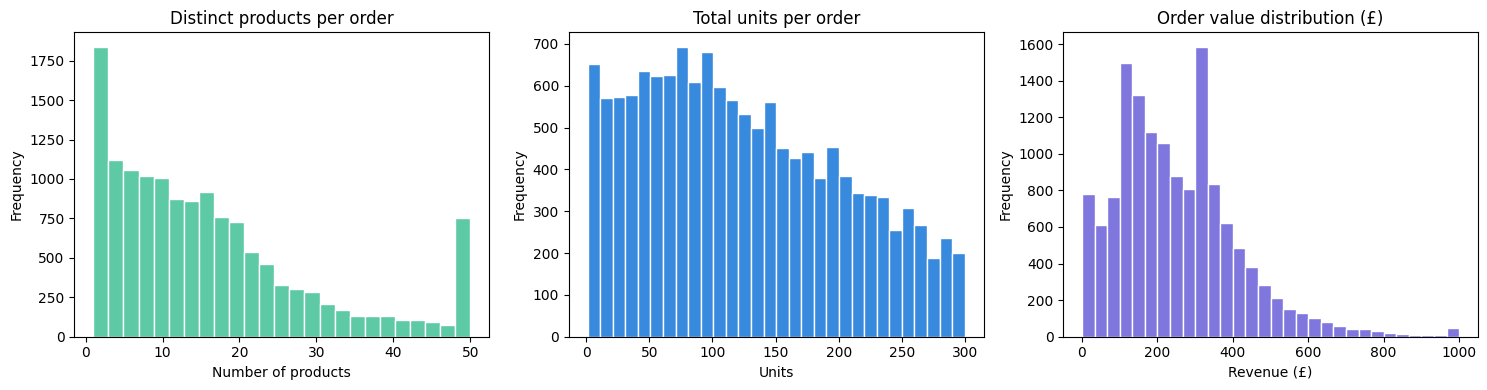

In [80]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(basket["Items"].clip(upper=50), bins=25,
           color="#5DCAA5", edgecolor="white")
ax[0].set_title("Distinct products per order")
ax[0].set_xlabel("Number of products")
ax[0].set_ylabel("Frequency")

ax[1].hist(basket["TotalQty"].clip(upper=300), bins=30,
           color="#378ADD", edgecolor="white")
ax[1].set_title("Total units per order")
ax[1].set_xlabel("Units")
ax[1].set_ylabel("Frequency")

ax[2].hist(basket["OrderRevenue"].clip(upper=1000), bins=30,
           color="#7F77DD", edgecolor="white")
ax[2].set_title("Order value distribution (£)")
ax[2].set_xlabel("Revenue (£)")
ax[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [81]:
# classify customers
customer_orders = sales_retail_df.groupby("CustomerID")["InvoiceNo"].nunique()

repeat_customers   = customer_orders[customer_orders > 1].index
onetime_customers  = customer_orders[customer_orders == 1].index

sales_retail_df["BuyerType"] = sales_retail_df["CustomerID"].apply(
    lambda x: "Repeat" if x in repeat_customers else "One-Time"
)

buyer_summary = (
    sales_retail_df
    .groupby("BuyerType")
    .agg(
        Revenue   = ("Revenue", "sum"),
        Customers = ("CustomerID", "nunique"),
        Orders    = ("InvoiceNo", "nunique")
    )
    .reset_index()
)
buyer_summary["Revenue_%"] = (
    buyer_summary["Revenue"] / buyer_summary["Revenue"].sum() * 100
).round(2)

print(buyer_summary)


  BuyerType     Revenue  Customers  Orders  Revenue_%
0  One-Time   377101.64       1520    1520      10.56
1    Repeat  3194299.48       2380   12477      89.44


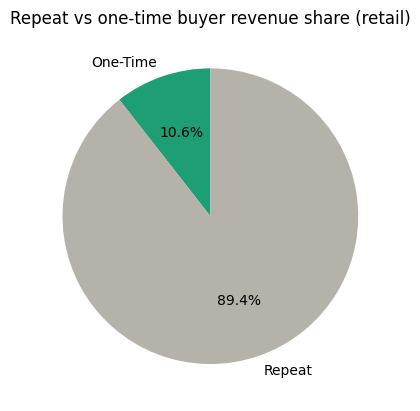

In [82]:

# pie chart
colors = ["#1D9E75", "#B4B2A9"]
plt.pie(
    buyer_summary["Revenue_%"],
    labels=buyer_summary["BuyerType"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)
plt.title("Repeat vs one-time buyer revenue share (retail)")
plt.show()

**Repeat customers (61% of the retail base) generate 89.4% of all retail revenue. One-time customers contribute only 10.6% despite representing 39% of the customer count. This is the single most important finding in the retail analysis — the business is almost entirely sustained by its loyal repeat buyer base. Acquiring new customers is significantly less impactful than retaining existing ones. A targeted loyalty or re-engagement programme for at-risk repeat buyers would have an outsized effect on revenue.**

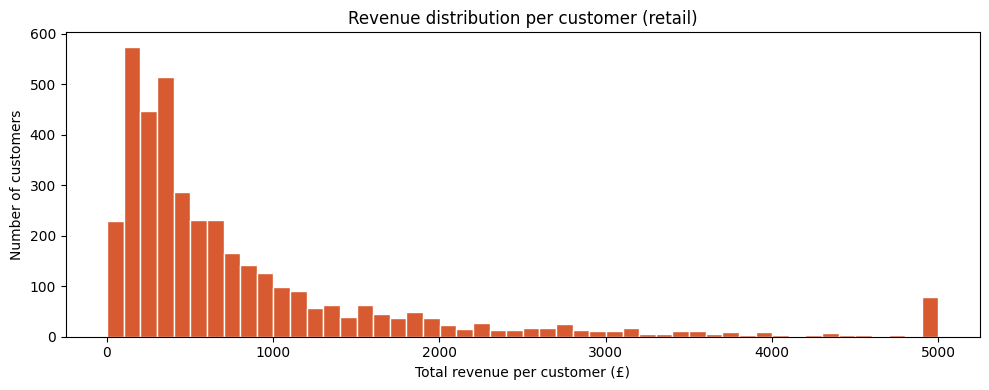

count     3900.00
mean       915.74
std       1642.09
min          3.75
25%        239.98
50%        466.41
75%        981.88
max      39916.50
Name: Revenue, dtype: float64


In [83]:
customer_revenue = sales_retail_df.groupby("CustomerID")["Revenue"].sum()

plt.figure(figsize=(10, 4))
plt.hist(customer_revenue.clip(upper=5000), bins=50,
         color="#D85A30", edgecolor="white")
plt.title("Revenue distribution per customer (retail)")
plt.xlabel("Total revenue per customer (£)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

print(customer_revenue.describe().round(2))

In [84]:
reference_date = sales_retail_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = sales_retail_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347,2,3,1192.25
12348,75,2,597.00
12350,310,1,294.40
12352,36,7,1385.74
12353,204,1,89.00


In [85]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

In [86]:
rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)


In [87]:
def segment_customer(row):

    if row["R_score"] == 5 and row["F_score"] >= 4:
        return "Champions"

    elif row["F_score"] >= 4:
        return "Loyal Customers"

    elif row["R_score"] >= 4:
        return "Recent Customers"

    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Lost Customers"

    else:
        return "Potential Loyalist"


rfm["Customer_segment"] = rfm.apply(segment_customer, axis=1)

In [88]:
badge_counts = rfm["Customer_segment"].value_counts()
badge_counts

,count
Customer_segment,
Loyal Customers,977
Lost Customers,931
Potential Loyalist,813
Recent Customers,596
Champions,583


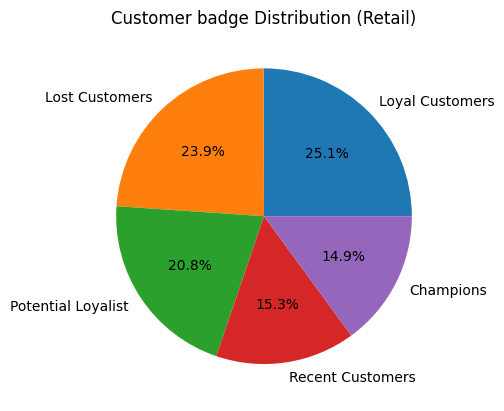

In [89]:
badge_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Customer badge Distribution (Retail)")
plt.ylabel("")

plt.show()

In [90]:
rfm = rfm.reset_index()
final_retail_df = sales_retail_df.merge(rfm, on="CustomerID", how="left")

In [91]:
final_retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,...,Order_Type,BuyerType,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Customer_segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,1,...,Retail,Repeat,372,34,5391.21,1,5,5,155,Loyal Customers
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,...,Retail,Repeat,372,34,5391.21,1,5,5,155,Loyal Customers
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,1,...,Retail,Repeat,372,34,5391.21,1,5,5,155,Loyal Customers
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,...,Retail,Repeat,372,34,5391.21,1,5,5,155,Loyal Customers
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,1,...,Retail,Repeat,372,34,5391.21,1,5,5,155,Loyal Customers


In [92]:
final_retail_df.groupby("Customer_segment")["Revenue"].sum().sort_values(ascending=False)

,Revenue
Customer_segment,
Champions,1458676.99
Loyal Customers,1316935.22
Potential Loyalist,344524.60
Lost Customers,231748.10
Recent Customers,219516.21


**RFM segmentation reveals that "Loyal Customers" (25.1%) and "Lost Customers" (23.9%) are almost equally sized — a warning sign. Champions (16.5%) and Loyal Customers together account for over £2.77 million in revenue (77.5% of retail revenue), making them the most critical segment to protect. The large "Lost Customers" group represents customers who purchased in early 2011 but never returned — these are strong candidates for a win-back campaign. "Potential Loyalists" (20.9%) are one nudge away from becoming loyal: a targeted discount or personalised recommendation could convert them.**

### 3.3 Wholesale Sales Analysis

In [93]:
sales_wholesale_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand,Order_Type
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583,France,90.0,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,£3–5,Wholesale
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583,France,90.0,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,£3–5,Wholesale
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583,France,45.0,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,£3–5,Wholesale
29,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583,France,10.2,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,<£1,Wholesale
30,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583,France,15.6,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,<£1,Wholesale


In [94]:
# observing the KPIs

summary_wholesale = {
    "Total Wholesale Revenue": sales_wholesale_df["Revenue"].sum(),
    "Total Wholesale Orders": sales_wholesale_df["InvoiceNo"].nunique(),
    "Total Wholesale Products": sales_wholesale_df["StockCode"].nunique(),
    "Total Wholesale Quantity Sold": sales_wholesale_df["Quantity"].sum(),
    "Total Wholesale Customers": sales_wholesale_df["CustomerID"].nunique()
}

sales_wholesale_summary_df = pd.DataFrame(summary_wholesale, index=["Value"])
sales_wholesale_summary_df

,Total Wholesale Revenue,Total Wholesale Orders,Total Wholesale Products,Total Wholesale Quantity Sold,Total Wholesale Customers
Value,4920170.42,4402,3376,3244041,1608


In [95]:
sales_wholesale_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Day,Month,Year,Hours
count,155013.000000,155013,155013.000000,155013.000000,155013.000000,155013.000000,155013.000000,155013.000000,155013.000000
mean,20.927542,2011-07-21 12:05:09.668092160,2.578923,15036.340946,31.740373,15.229432,7.697883,2010.955410,12.639146
min,1.000000,2010-12-01 08:45:00,0.040000,12347.000000,0.120000,1.000000,1.000000,2010.000000,7.000000
25%,3.000000,2011-04-26 08:33:00,0.850000,13629.000000,7.500000,8.000000,5.000000,2011.000000,11.000000
50%,10.000000,2011-08-19 09:38:00,1.650000,14911.000000,15.000000,15.000000,9.000000,2011.000000,13.000000
75%,20.000000,2011-10-21 10:50:00,2.950000,16535.000000,23.400000,22.000000,10.000000,2011.000000,14.000000
max,4800.000000,2011-12-09 12:19:00,295.000000,18287.000000,7144.720000,31.000000,12.000000,2011.000000,20.000000
std,65.885509,NaN,3.501095,1707.387120,106.424258,8.590415,3.311734,0.206402,2.283652


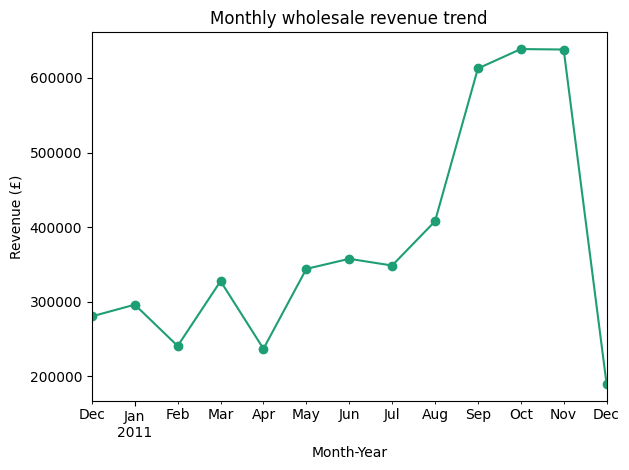

In [96]:
monthly_wholesale = sales_wholesale_df.groupby("MonthYear")["Revenue"].sum()

monthly_wholesale.plot(kind="line", marker="o", color="#1D9E75")
plt.title("Monthly wholesale revenue trend")
plt.xlabel("Month-Year")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

**Wholesale revenue shows a similar seasonal shape to retail but with more volatility. Large single-order spikes are visible in certain months, which is expected in a B2B channel where one big order can shift the monthly total significantly. The November peak is present but less dramatic than in retail — wholesale buyers plan further ahead and spread their orders more evenly across Q3 and Q4. Wholesale revenue is more predictable on an annual basis but harder to forecast month-to-month.**

In [97]:
# creating the pivot table — rows = days, columns = hours, values = unique orders
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot_wholesale = (
    sales_wholesale_df
    .groupby(["DayOfWeek", "Hours"])["InvoiceNo"]
    .nunique()
    .reset_index()
    .pivot(index="DayOfWeek", columns="Hours", values="InvoiceNo")
    .reindex(day_order)   # forces correct Mon→Sun order on y-axis
    .fillna(0)
    .astype(int)        # hours with no orders become 0 instead of NaN
)
pivot_wholesale

Hours,7,8,9,10,11,12,13,14,15,16,17,18,19,20
DayOfWeek,,,,,,,,,,,,,,
Monday,1,28,69,101,72,125,117,84,74,38,17,0,0,0
Tuesday,1,32,78,117,112,132,114,94,80,31,13,0,0,0
Wednesday,2,25,66,126,122,130,114,108,89,42,16,0,0,1
Thursday,3,24,85,120,87,143,100,104,94,63,52,35,15,6
Friday,4,24,65,100,91,129,94,79,58,25,13,0,0,0
Saturday,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Sunday,0,0,0,32,70,87,84,56,73,16,0,0,0,0


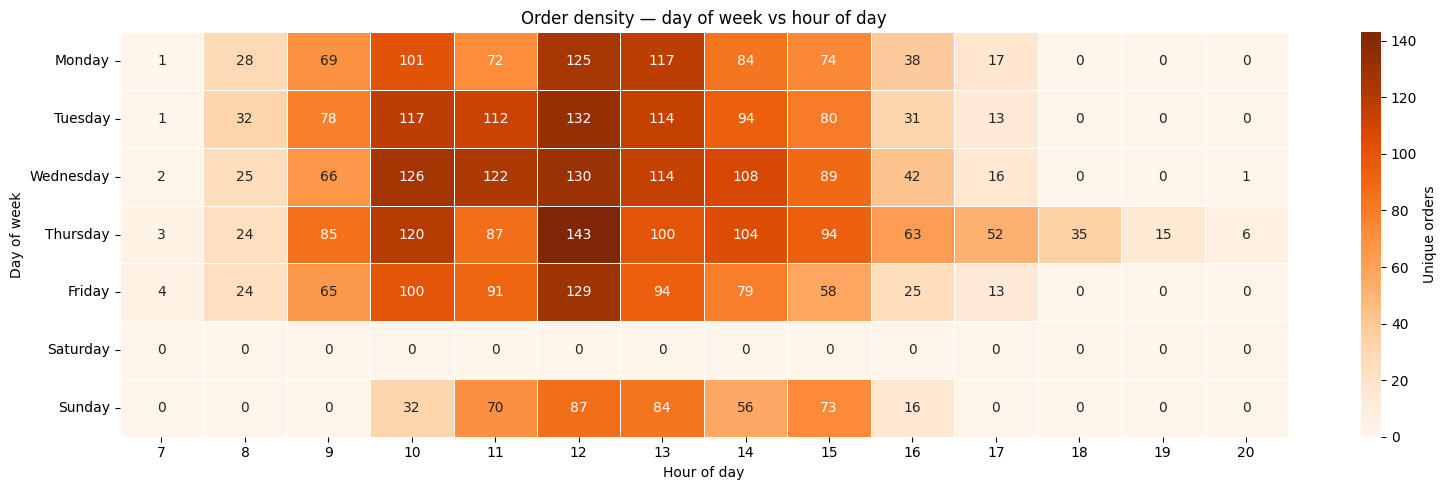

In [98]:
# plotting a heatmap to understand more clearly

plt.figure(figsize=(16, 5))

sns.heatmap(
    pivot_wholesale,
    cmap="Oranges",
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt="d",
    cbar_kws={"label": "Unique orders"}
)

plt.title("Order density — day of week vs hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()

**Wholesale ordering is more evenly distributed across the day compared to retail, though the midday peak (11:00–13:00) remains the busiest window. Wholesale buyers tend to start earlier in the morning (orders visible from 07:00) and finish by 17:00 — a tighter business-hours pattern than retail. Thursday remains the peak day for wholesale as well. This confirms that wholesale customers are professional buyers operating on business schedules.**

In [99]:
bulk_orders = sales_wholesale_df.groupby("InvoiceNo").agg({
    "Quantity":"sum",
    "Revenue":"sum"
})

bulk_orders.sort_values("Quantity",ascending=False).head(10)

,Quantity,Revenue
InvoiceNo,,
556917,15049,22775.93
563076,14730,19150.66
572035,13392,20277.92
567423,12572,31698.16
552883,12266,14415.74
563614,12196,21880.44
562439,11848,18841.48
548011,11116,15719.56
545475,10272,16726.84


In [100]:
bulk_orders["avg_price"] = bulk_orders["Revenue"] / bulk_orders["Quantity"]

bulk_orders.sort_values("Quantity",ascending=False).head(10)

,Quantity,Revenue,avg_price
InvoiceNo,,,
556917,15049,22775.93,1.513451
563076,14730,19150.66,1.300113
572035,13392,20277.92,1.514182
567423,12572,31698.16,2.521330
552883,12266,14415.74,1.175260
563614,12196,21880.44,1.794067
562439,11848,18841.48,1.590267
548011,11116,15719.56,1.414138
545475,10272,16726.84,1.628392


In [101]:
top_bulk_invoices = bulk_orders.sort_values("Quantity", ascending=False).head(10).index

In [102]:
bulk_df = sales_wholesale_df[sales_wholesale_df["InvoiceNo"].isin(top_bulk_invoices)]

bulk_products = bulk_df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

bulk_products

,Quantity
Description,
ASSORTED COLOUR BIRD ORNAMENT,3040
SPACEBOY LUNCH BOX,2112
DOLLY GIRL LUNCH BOX,2112
PINK VINTAGE SPOT BEAKER,2040
GREEN VINTAGE SPOT BEAKER,2040
...,...
CLASSIC FRENCH STYLE BASKET GREEN,8
CIRCUS PARADE BABY GIFT SET,6
GREEN GOOSE FEATHER CHRISTMAS TREE,6


In [103]:
bulk_customers = bulk_df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
bulk_customers

,Revenue
CustomerID,
14646,69563.88
12415,61383.21
17450,31698.16
12931,18841.48
13694,3027.31


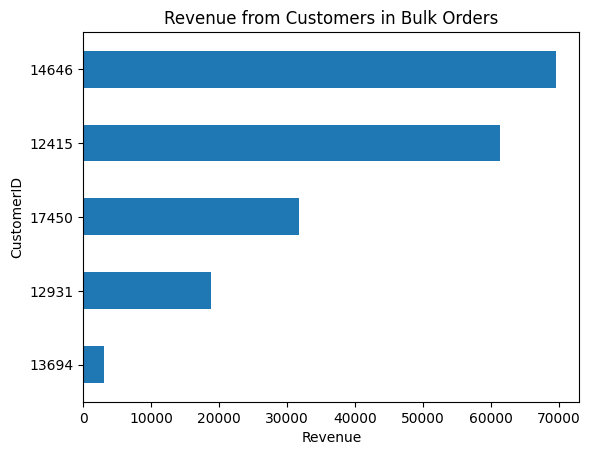

In [104]:
bulk_customers.sort_values().plot(kind="barh")

plt.title("Revenue from Customers in Bulk Orders")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")


plt.show()

**Customer 14646 is the dominant wholesale buyer at £69,563 in bulk orders alone, followed by customer 12415 at £61,383. These top bulk buyers are critical accounts — losing even one would have a measurable impact on wholesale revenue. The business should ensure these customers have a dedicated account manager and receive priority service for stock availability and order fulfilment.**

In [105]:
wholesale_customer_rev = (
    sales_wholesale_df.groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index()
    .rename(columns={"Revenue": "NetRevenue"})
)

wholesale_customer_rev["tier"] = pd.qcut(
    wholesale_customer_rev["NetRevenue"],
    q=[0, 0.5, 0.8, 1],
    labels=["Silver", "Gold", "Platinum"],
    duplicates="drop"
)

In [106]:
tier_counts = wholesale_customer_rev["tier"].value_counts()

tier_counts

,count
tier,
Silver,804
Gold,482
Platinum,322


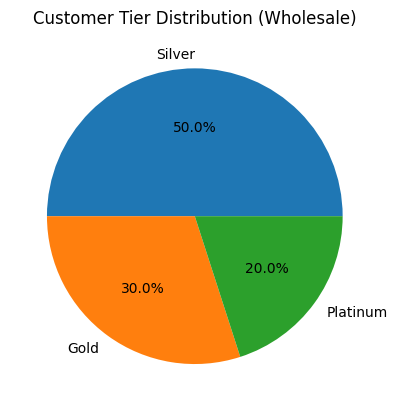

In [107]:
tier_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Customer Tier Distribution (Wholesale)")
plt.ylabel("")

plt.show()

In [108]:
sales_wholesale_df = sales_wholesale_df.merge(wholesale_customer_rev[["CustomerID","tier"]],on="CustomerID",how="left")

In [109]:
sales_wholesale_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand,Order_Type,tier
0,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583,France,90.0,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,£3–5,Wholesale,Platinum
1,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583,France,90.0,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,£3–5,Wholesale,Platinum
2,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583,France,45.0,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,£3–5,Wholesale,Platinum
3,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583,France,10.2,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,<£1,Wholesale,Platinum
4,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583,France,15.6,1,12,2010,2010-12,08:45:00,8,Wednesday,Weekday,<£1,Wholesale,Platinum


In [110]:
invoice_level = (
    sales_wholesale_df
    .groupby(["InvoiceNo", "tier"], observed=True)["Revenue"]
    .sum()
    .reset_index()
)
invoice_level.sort_values("Revenue", ascending=False).head(10)

,InvoiceNo,tier,Revenue
2848,567423,Platinum,31698.16
1708,556917,Platinum,22775.93
3451,572209,Platinum,22206.00
2844,567381,Platinum,22104.80
2415,563614,Platinum,21880.44
1151,550461,Platinum,21535.90
3431,572035,Platinum,20277.92
2354,563076,Platinum,19150.66
2280,562439,Platinum,18841.48
351,541220,Platinum,16774.72


In [111]:
tier_AvgOrder_value = (
    invoice_level
    .groupby("tier", observed=True)["Revenue"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"Revenue": "Avg_Order_Value"})
)
tier_AvgOrder_value

,tier,Avg_Order_Value
0,Silver,494.17
1,Gold,698.28
2,Platinum,1550.46


**50% of wholesale customers fall into the Silver tier, 30% into Gold, and 20% into Platinum. However, Platinum customers — despite being the smallest group — generate an average order value of £1,550 compared to Silver's £494. This means the top 20% of wholesale customers are ordering at 3x the value of the bottom 50%. Protecting and growing the Platinum segment should be the primary wholesale growth lever.**

### 3.4 Risk analysis

In [112]:
return_df.shape

(8506, 15)

In [113]:
return_df.rename(columns={"ReturnValue": "Revenue"}, inplace=True)

In [114]:
net_df = pd.concat([sales_df, return_df], ignore_index=True)
net_df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Day,Month,Year,MonthYear,Time,Hours,DayOfWeek,DayType,PriceBand,Order_Type
399647,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,14397,United Kingdom,-23.40,9,12,2011,2011-12,09:57:00,NaN,Friday,NaN,NaN,NaN
399648,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom,-9.13,9,12,2011,2011-12,09:57:00,NaN,Friday,NaN,NaN,NaN
399649,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom,-54.75,9,12,2011,2011-12,11:57:00,NaN,Friday,NaN,NaN,NaN
399650,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom,-1.25,9,12,2011,2011-12,11:58:00,NaN,Friday,NaN,NaN,NaN
399651,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,17315,United Kingdom,-6.25,9,12,2011,2011-12,11:58:00,NaN,Friday,NaN,NaN,NaN


In [115]:
net_revenue = net_df["Revenue"].sum()
print(net_revenue)

8019820.83


In [116]:
top_net_products = net_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_net_products

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,132567.70
WHITE HANGING HEART T-LIGHT HOLDER,93767.80
JUMBO BAG RED RETROSPOT,83056.52
PARTY BUNTING,67628.43
ASSORTED COLOUR BIRD ORNAMENT,56331.91
RABBIT NIGHT LIGHT,51042.84
CHILLI LIGHTS,45915.41
PAPER CHAIN KIT 50'S CHRISTMAS,41423.78
PICNIC BASKET WICKER 60 PIECES,39619.50


In [117]:
top_net_products_pct = (top_net_products / net_revenue) * 100
top_net_products_pct

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,1.653001
WHITE HANGING HEART T-LIGHT HOLDER,1.169201
JUMBO BAG RED RETROSPOT,1.035641
PARTY BUNTING,0.843266
ASSORTED COLOUR BIRD ORNAMENT,0.702409
RABBIT NIGHT LIGHT,0.636459
CHILLI LIGHTS,0.572524
PAPER CHAIN KIT 50'S CHRISTMAS,0.516518
PICNIC BASKET WICKER 60 PIECES,0.494020


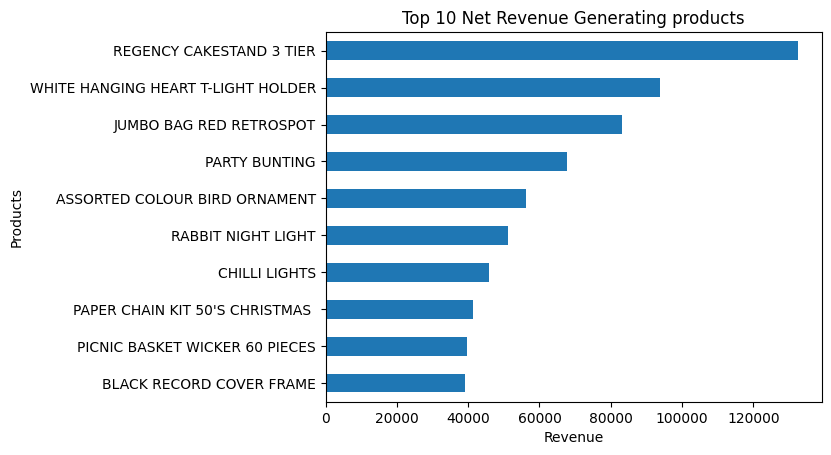

In [118]:
top_net_products.sort_values().plot(kind="barh")

plt.title("Top 10 Net Revenue Generating products")
plt.xlabel("Revenue")
plt.ylabel("Products")

plt.show()

In [119]:
product_net_rev = (
    net_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
product_net_rev = product_net_rev[product_net_rev["Revenue"] > 0]
product_net_rev["cumulative_pct"] = (
    product_net_rev["Revenue"].cumsum() / product_net_rev["Revenue"].sum() * 100
)

cutoff_idx = (product_net_rev["cumulative_pct"] <= 80).sum()
cutoff_pct = (cutoff_idx / len(product_net_rev)) * 100
total_products = len(product_net_rev)

print(f"Total wholesale products : {total_products}")
print(f"Top {cutoff_pct:.1f}% products ({cutoff_idx}) → 80% of wholesale revenue")
print(f"Bottom {100-cutoff_pct:.1f}% products ({total_products - cutoff_idx})")

Total wholesale products : 3849
Top 21.7% products (835) → 80% of wholesale revenue
Bottom 78.3% products (3014)


**Product concentration risk is significant — just `21.7%` of products (835 out of 3,849) drive `80%` of total net revenue. The remaining 78.3% of the product catalogue (3,014 products) contributes only 20% of revenue.**

**This means the business is heavily dependent on a relatively small core product range. If even a handful of the top-performing SKUs face supply issues, quality problems, or demand shifts, the revenue impact would be disproportionately large.**

**The long tail of 3,014 low-revenue products raises a separate question: Are these products worth maintaining? Dead stock ties up warehouse space and working capital. Dropping products that contribute less than 0.01% of revenue — could meaningfully improve operational efficiency without any material revenue loss and company can experiment by introducing new products to the market.**

In [121]:
top_net_country = net_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
top_net_country

,Revenue
Country,
United Kingdom,6556889.48
Netherlands,283479.54
EIRE,246732.47
Germany,200619.66
France,181385.54
Australia,136922.50
Switzerland,51859.40
Spain,51746.65
Belgium,36662.96


In [122]:
top_net_country_pct = (top_net_country / net_revenue) * 100
top_net_country_pct

,Revenue
Country,
United Kingdom,81.758553
Netherlands,3.534737
EIRE,3.076533
Germany,2.501548
France,2.261716
Australia,1.707301
Switzerland,0.646640
Spain,0.645234
Belgium,0.457154


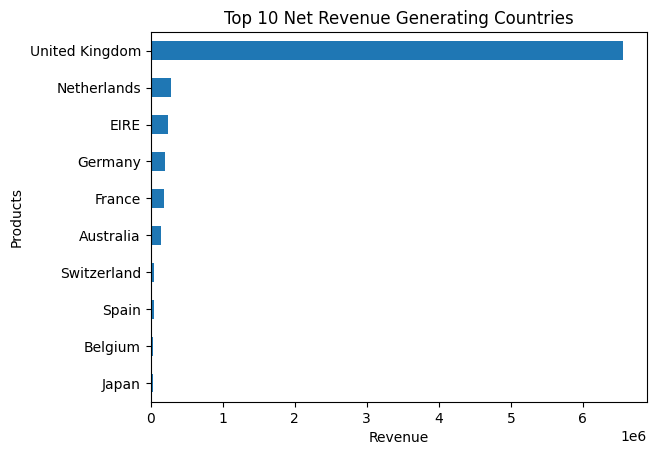

In [123]:
top_net_country.sort_values().plot(kind="barh")

plt.title("Top 10 Net Revenue Generating Countries")
plt.xlabel("Revenue")
plt.ylabel("Products")

plt.show()

**As we have seen earlier the absolute dependency of the business on UK market can be a `Risk factor`. Business should get more data about delivery details, shipping details for the other countries to get the root cause of this scenario**

In [124]:
top_net_customer = net_df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)
top_net_customer

,Revenue
CustomerID,
14646,278778.02
18102,259657.30
17450,189575.53
14911,128768.24
12415,123638.18
14156,113685.77
17511,88138.20
16684,65920.12
13694,62961.54


In [125]:
top_net_customer_pct = (top_net_customer / net_revenue) * 100
top_net_customer_pct

,Revenue
CustomerID,
14646,3.476113
18102,3.237695
17450,2.363837
14911,1.605625
12415,1.541658
14156,1.417560
17511,1.099005
16684,0.821965
13694,0.785074


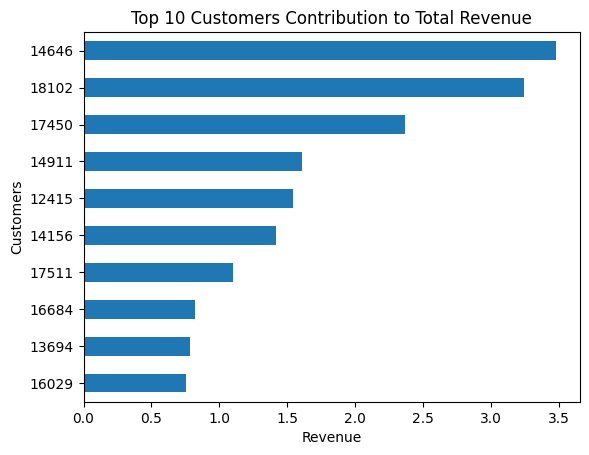

In [126]:
top_net_customer_pct.sort_values().plot(kind="barh")

plt.title("Top 10 Customers Contribution to Total Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customers")

plt.show()

In [127]:

customer_net_rev = (
    net_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
customer_net_rev = customer_net_rev[customer_net_rev["Revenue"] > 0]
customer_net_rev["cumulative_pct"] = (
    customer_net_rev["Revenue"].cumsum() / customer_net_rev["Revenue"].sum() * 100
)

cutoff_idx = (customer_net_rev["cumulative_pct"] <= 80).sum()
cutoff_pct = (cutoff_idx / len(customer_net_rev)) * 100
total_customers = len(customer_net_rev)

print(f"Total wholesale customers : {total_customers}")
print(f"Top {cutoff_pct:.1f}% customers ({cutoff_idx}) → 80% of wholesale revenue")
print(f"Bottom {100-cutoff_pct:.1f}% customers ({total_customers - cutoff_idx})")

Total wholesale customers : 4324
Top 26.9% customers (1165) → 80% of wholesale revenue
Bottom 73.1% customers (3159)


**Just `26.9%` of customers (1,165 out of 4,324) drive `80%` of total net revenue. The remaining 73.1% of customers contribute only 20%. This is a textbook Pareto distribution and confirms that customer concentration risk is real — a targeted retention strategy for the top quartile of customers is essential. Losing 10% of the top customer group would have a greater revenue impact than losing 50% of the bottom group.**
 **Combined with the earlier finding that the top `21.7%` of products (835 out of 3,849) drive `80%` of total net revenue, the business faces a ***dual concentration risk*** — both on the customer side and the product side..**

In [128]:
customer_orders = sales_df.groupby("CustomerID")["InvoiceNo"].nunique()

one_time_customers = customer_orders[customer_orders == 1].count()
one_time_customers

np.int64(1504)

In [129]:
total_customers = customer_orders.count()

total_customers

np.int64(4332)

In [130]:
one_time_pct = (one_time_customers / total_customers) * 100
one_time_pct

np.float64(34.71837488457987)

**34.7% of all customers — over 1 in 3 — placed only a single order and never returned. This churn rate represents significant lost lifetime value. If even half of these one-time buyers could be converted to repeat customers, the revenue impact would be substantial. Common reasons for one-time purchasing include poor post-purchase experience, lack of follow-up communication, or simply not finding the right product on the first visit. An automated post-purchase email sequence with personalised recommendations could meaningfully reduce this rate.**

## 4. Final Section

 #### Conclusion & Recommendations
Business Summary

This UK-based e-commerce retailer operates a high-volume, low-margin gifting and homeware business with a dual-channel model — serving both individual retail consumers and wholesale B2B buyers. Over the 13-month period analysed (December 2010 – December 2011), the business generated a **net revenue of approximately £8.02 million** across 18,400+ orders from 4,300+ customers. After removing two outlier bulk-cancel transactions (customers 16446 and 12346), the data reflects clean, actionable patterns.

---

Key Findings

**1. This is a B2B-dominant, weekday-only business.**
Over 91% of revenue is generated Monday–Friday, with near-zero weekend activity. The customer base behaves like professional buyers, not individual consumers. All marketing, staffing, and operational decisions should be anchored to the Tuesday–Thursday, 10:00–14:00 window.

**2. The £1–3 price band drives the business.**
Nearly 50% of all revenue comes from products priced between £1 and £3. This is a volume-driven, low-price model. Premium products (£20+) contribute only 1.2% of revenue and are not a meaningful growth lever.

**3. Repeat customers are everything.**
In the retail segment, repeat buyers (61% of customers) generate 89.4% of revenue. Retaining existing customers is dramatically more valuable than acquiring new ones. The 34.7% one-time customer rate represents the biggest untapped growth opportunity.

**4. A large "Lost Customer" segment requires immediate attention.**
RFM analysis shows nearly 24% of retail customers are classified as "Lost" — they purchased early in 2011 and never returned. A structured win-back campaign targeting this segment could recover a meaningful portion of lapsed revenue.

**5. Revenue is heavily concentrated.**
The top 26.9% of customers generate 80% of revenue. The top 10 customers alone account for 17% of net revenue. The business carries significant customer concentration risk, particularly in the wholesale channel.

**6. The UK market dependency is a strategic risk.**
82% of revenue comes from the UK. Any economic disruption, regulatory change, or market shift in the UK directly threatens the majority of the business. International expansion — starting with the Netherlands, EIRE, and Germany (the next three markets) — should be a long-term strategic priority.

**7. Wholesale Platinum customers are the highest-value segment.**
Platinum wholesale customers order at 3x the average order value of Silver customers. Protecting, growing, and adding to this segment is the single highest-ROI wholesale growth action.

---

Recommendations

| Priority | Action | Target Segment | Expected Impact |
|---|---|---|---|
| 🔴 High | Launch win-back email campaigns | Lost Customers (RFM) | Recover lapsed retail revenue |
| 🔴 High | Introduce loyalty programme | Champions + Loyal Customers | Reduce churn in top revenue segment |
| 🔴 High | Assign dedicated account managers, offers and discounts two months before festival period| Wholesale Platinum customers | Protect high-value B2B accounts |
| 🟡 Medium | Post-purchase email sequence, Assigning limited time prime deals only for repeat customers| One-time buyers (34.7%) | Convert to repeat buyers |
| 🟡 Medium | Seasonal inventory planning | All segments | Prevent Q4 stockouts (Nov peak) |
| 🟡 Medium | Nudge campaign for Potential Loyalists | RFM Potential Loyalist segment | Upgrade to Loyal Customer tier |
| 🟢 Low | Explore international expansion | Netherlands, EIRE, Germany | Reduce UK market dependency |
| 🟢 Low | Review premium product strategy | £20+ price band | Assess if worth continuing |

---

Limitations & Next Steps

- **Return rate analysis by product** — identifying which SKUs have the highest return rates would help flag quality or listing issues.
- **Cohort analysis** — Cohort analysis was not conducted as the dataset covers only 13 months. A meaningful cohort requires 2–3 years of data to observe long-term retention patterns and avoid incomplete cohort bias in the later months.
- **Churn prediction model** — using the RFM scores and purchase history, a simple ML model could predict which customers are likely to churn before they actually do.
- **Wholesale customer profiling** — understanding which industries or geographies the wholesale customers come from would help tailor B2B outreach.

---

***Additional weak point:***
**The data isn't complete and compact, the business should extract more data like `delivered date`,`cancellation reasons`, `product category` etc. Then we can deep dive into customer behaviour to ensure the stability and growth of the business**


*Analysis conducted on the UCI Online Retail Dataset | Tools: Python, Pandas, Matplotlib, Seaborn | Period: Dec 2010 – Dec 2011*

In [131]:
 # Save all important DataFrames as CSV files

sales_df.to_csv("sales_df.csv", index=False)
return_df.to_csv("return_df.csv", index=False)
sales_wholesale_df.to_csv("sales_wholesale_df.csv", index=False)
final_retail_df.to_csv("final_retail_df.csv", index=False)
bulk_df.to_csv("bulk_df.csv", index=False)
net_df.to_csv("net_df.csv", index=False)